# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Boosting Methods Capstone Project (Titanic Prediction)</b></p>


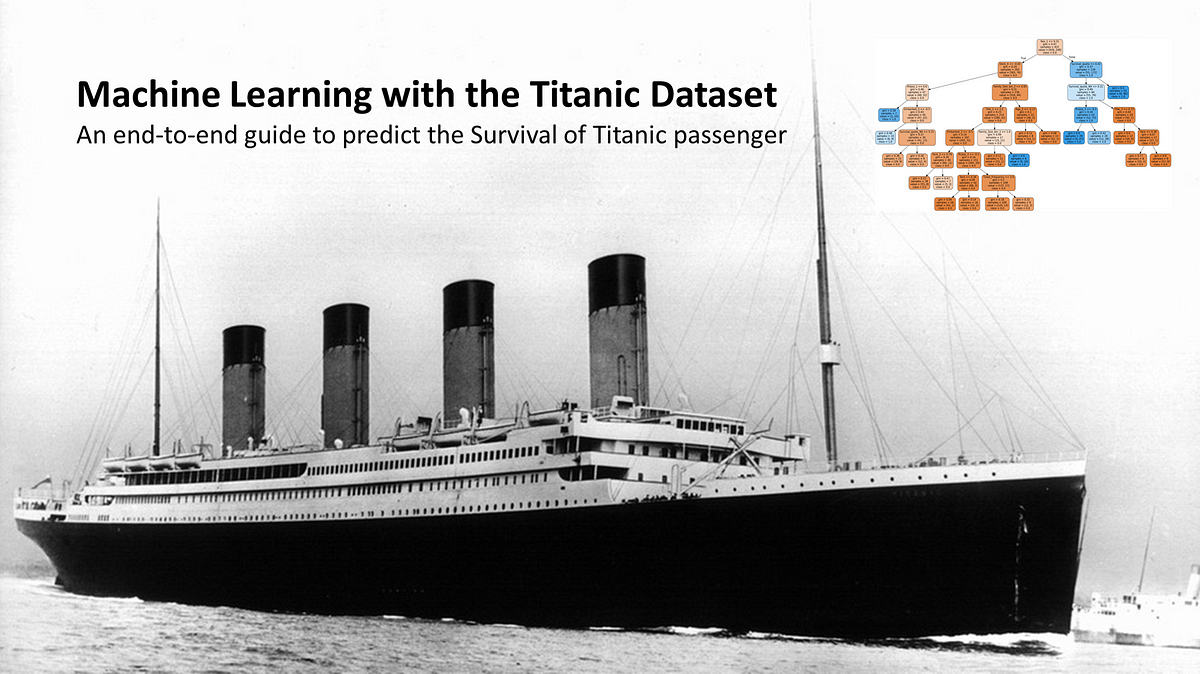

Makine öğrenmesi dünyasının meşhur problemi (bir proje) olan Titanic data seti ile tanışmaya hoş geldiniz arkadaşlar. Bu projemiz bir Kaggle Projesi olup sıklıkla kullanılan bir gerçek dünya data setidir. Data seti ile ilgili açıklamaya alttaki linkten ulaşabilirsiniz.

https://www.kaggle.com/c/titanic/overview

Bu problemde amacımız yukarıdaki linkteki görevi yerine getirmek.

**Önemli Not:** Kaggle yarışmalarında bazen data,
* train data
* test data
olarak ayrı verilir.

Buradaki test data bizim model oluştururken kullanacağımız test data değildir.

Bu test data Kaggle'in yarışma sonuçları test etmek için kullandığı datadır.

Dolayısı ile bu test data içinde target variable yani gerçek label değeri (grand truth) bulunmaz.

Bu sebeple kendi model doğruluğumuzu ölçerken bu test datayı kullanamayacağınızdan mevcut train data ile train_test_split yaparak kendi test datanızı oluşturmayı unutmayın!

## ---------------------------- Titanic - Machine Learning from Disaster-----------------------------

## Project Summary: 

- 15 Nisan 1912'de, ilk seferinde, Titanik bir buzdağına çarptıktan sonra battı ve 2224 yolcu ve mürettebattan 1502'si hayatını kaybetti. Bu sansasyonel trajedi uluslararası toplumu şok etti ve gemiler için daha iyi güvenlik düzenlemelerine yol açtı.
Gemi kazasının bu kadar can kaybına yol açmasının nedenlerinden biri, yolcular ve mürettebat için yeterli cankurtaran botunun olmamasıydı. Batıştan sağ kurtulmada bir miktar şans faktörü olsa da, kadınlar, çocuklar ve üst sınıf gibi bazı grupların hayatta kalma olasılığı diğerlerinden daha yüksekti.

- Projenin amacı, yaş, cinsiyet, bilet ücreti ve kabin sınıfı gibi özelliklere dayanarak hangi yolcuların felaketten sağ kurtulduğunu tahmin etmektir. Her yolcu için hayatta kalma sonucunu doğru bir şekilde tahmin edebilemek için Boosting Methods kullanılacak score en iyi olan model ile final makine öğrenme modeli geliştirilecektir.

- Data Set :


   Veri Kümesi Sütunları Aşağıdaki gibidir.
    1. PassengerId  --> Yolcu ID numarası ( Benzersiz kimlik sütunu)
    2. Survived --> Hayatta kalma durumu (Hedef değişken (0 = öldü, 1 = kurtuldu) )
    3. Pclass -->  Bilet sınıfı (Sosyoekonomik durumu temsil eder )
    4. Name -->  Yolcu adı
    5. Sex -->  Cinsiyet
    6. Age --> Yaş
    7. SibSp --> Kardeş/eş sayısı (Aile ilişkisi bilgisi)
    8. Parch --> Ebeveyn/çocuk sayısı (Aile büyüklüğü gösterir)
    9. Ticket --> Bilet numarası
    10. Fare --> Bilet ücreti
    11. Cabin -->  Kabin bilgisi
    12. Embarked --> Biniş limanı    


## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier    # pip install catboost
from lightgbm import LGBMClassifier    # pip install lightgbm
from xgboost import XGBClassifier    # pip install xgboost

from lazypredict.Supervised import LazyClassifier    # pip install lazypredict

## Read Data

In [2]:
gender = pd.read_csv("gender_submission.csv")
gender.head(5)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [3]:
train= pd.read_csv("train.csv")
train.head(5)
# eğitilecek olan train seti 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test = pd.read_csv("test.csv")
test.head(5)
# tahminlerin alınacağı test seti. 

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Data Preparation and Exploratory Data Analysis (EDA)

In [5]:
df = train.copy()
df_test = test.copy()

In [6]:
df.shape
# 891 gözlem , 12 feature var 

(891, 12)

In [7]:
df.info()

# Verisetinde; toplam 891 satır (gözlem),  12 sütun (özellik/değişken) bulunuyor.
# Veri tipleri: int64 → 5 adet sayısal tam sayı değişkeni ,float64 → 2 adet ondalıklı sayısal değişken ,object → 5 adet kategorik/metinsel değişken
#Age , Cabin, Embarked featurelerde eksik veriler mevcuttur. 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df_test.shape
# 418 gözlem , 11 feature var (target =survived içinde bulunmaz drop edilmiştir.)
#Survived hedef değişkendi.Test verisinde bilinçli olarak kaldırılmıştır.Amaç: modelin tahmin yapması.

(418, 11)

In [9]:
df_test.info()

# Veri setinde; toplam 418 gözlem (satır) , 11 sütun bulunuyor.
# Veri tipleri: int64 → 4 sütun, float64 → 2 sütun ,object → 5 sütun
# #Age , Cabin, Embarked featurelerde eksik veriler mevcuttur. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [10]:
def column_info(df):
    """
    Generate summary information for each column in the DataFrame.

    Parameters:
    df (DataFrame): Input DataFrame.

    Returns:
    DataFrame: DataFrame containing summary information for each column.
    """
    info = []
    for col in df.columns:
        data_type = df[col].dtype
        count = len(df[col])
        nan_count = df[col].isnull().sum()
        nan_percent = (nan_count / count) * 100 if count > 0 else 0
        unique_count = df[col].nunique()

        if pd.api.types.is_numeric_dtype(df[col]):
            max_value = df[col].max()
            min_value = df[col].min()
            sample_value = df[col].dropna().sample().iloc[0] if count - nan_count > 0 else None
        else:
            sample_value = df[col].dropna().sample().iloc[0] if count - nan_count > 0 else None
            max_value = 'no value'
            min_value = 'no value'

        info.append({
            'Column_name': col,
            'Data_Type': data_type,
            'Count': count,
            'NaN_Count': nan_count,
            'NaN_Percent': nan_percent,
            'Unique_Count': unique_count,
            'Max_Value': max_value,
            'Min_Value': min_value,
            'Sample_Value': sample_value
        })

    return pd.DataFrame(info)

In [11]:
column_info(df)
# PassengerId : 891 tane unique değeri, her yolcu için benzersiz ID vardır. Model için anlamlı bilgi taşımaz.
# Survived : target hedef değişkendir .0 → Hayatta kalmadı , 1 → Hayatta kaldı
# Pclass  : Yolcunun sosyal sınıfını temsil eden 3 tane sınıf vardır. 1 → Üst sınıf, 2 → Orta sınıf, 3 → Alt sınıf
# Name : 891 tane unique değeri vardır. Her isim benzersiz. 
# Sex : Çok güçlü bir kategorik değişken. male, female olarak iki unique değer vardır.
# Age : 177 tane NaN value missing value vardır. 88 tane unique değer vardır. Min: 0.42(5 aylık bebek), max : 80 yaş  dağılım geniş aralıkta outlier olabilir.
# SibSp : 7 tane unique değeri vardır. Gemideki kardeş/eş sayısı.
# Parch : 7 tane unique değer vardır . Gemideki ebeveyn/çocuk sayısı.
# Ticket : 681 tane unique değeri vardır .Düzensiz formatta , çok fazla benzersiz değer.Yüksek kardinaliteye sahip.
# Fare : 248 tane unique değeri vardır .Dağılım sağa çarpık olabilir . Outlier içeriyor olabilir
# Cabin : 687 tane NaN value missing value vardır.
# Embarked : Biniş limanı bilgisidir. 3 tane unique değer ve 2 tane NaN value missing value vardır.


,Column_name,Data_Type,Count,NaN_Count,NaN_Percent,Unique_Count,Max_Value,Min_Value,Sample_Value
0,PassengerId,int64,891,0,0.000000,891,891,1,120
1,Survived,int64,891,0,0.000000,2,1,0,1
2,Pclass,int64,891,0,0.000000,3,3,1,3
3,Name,object,891,0,0.000000,891,no value,no value,"Harris, Mr. George"
4,Sex,object,891,0,0.000000,2,no value,no value,male
5,Age,float64,891,177,19.865320,88,80.0,0.42,26.0
6,SibSp,int64,891,0,0.000000,7,8,0,0
7,Parch,int64,891,0,0.000000,7,6,0,0
8,Ticket,object,891,0,0.000000,681,no value,no value,54636
9,Fare,float64,891,0,0.000000,248,512.3292,0.0,7.125


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

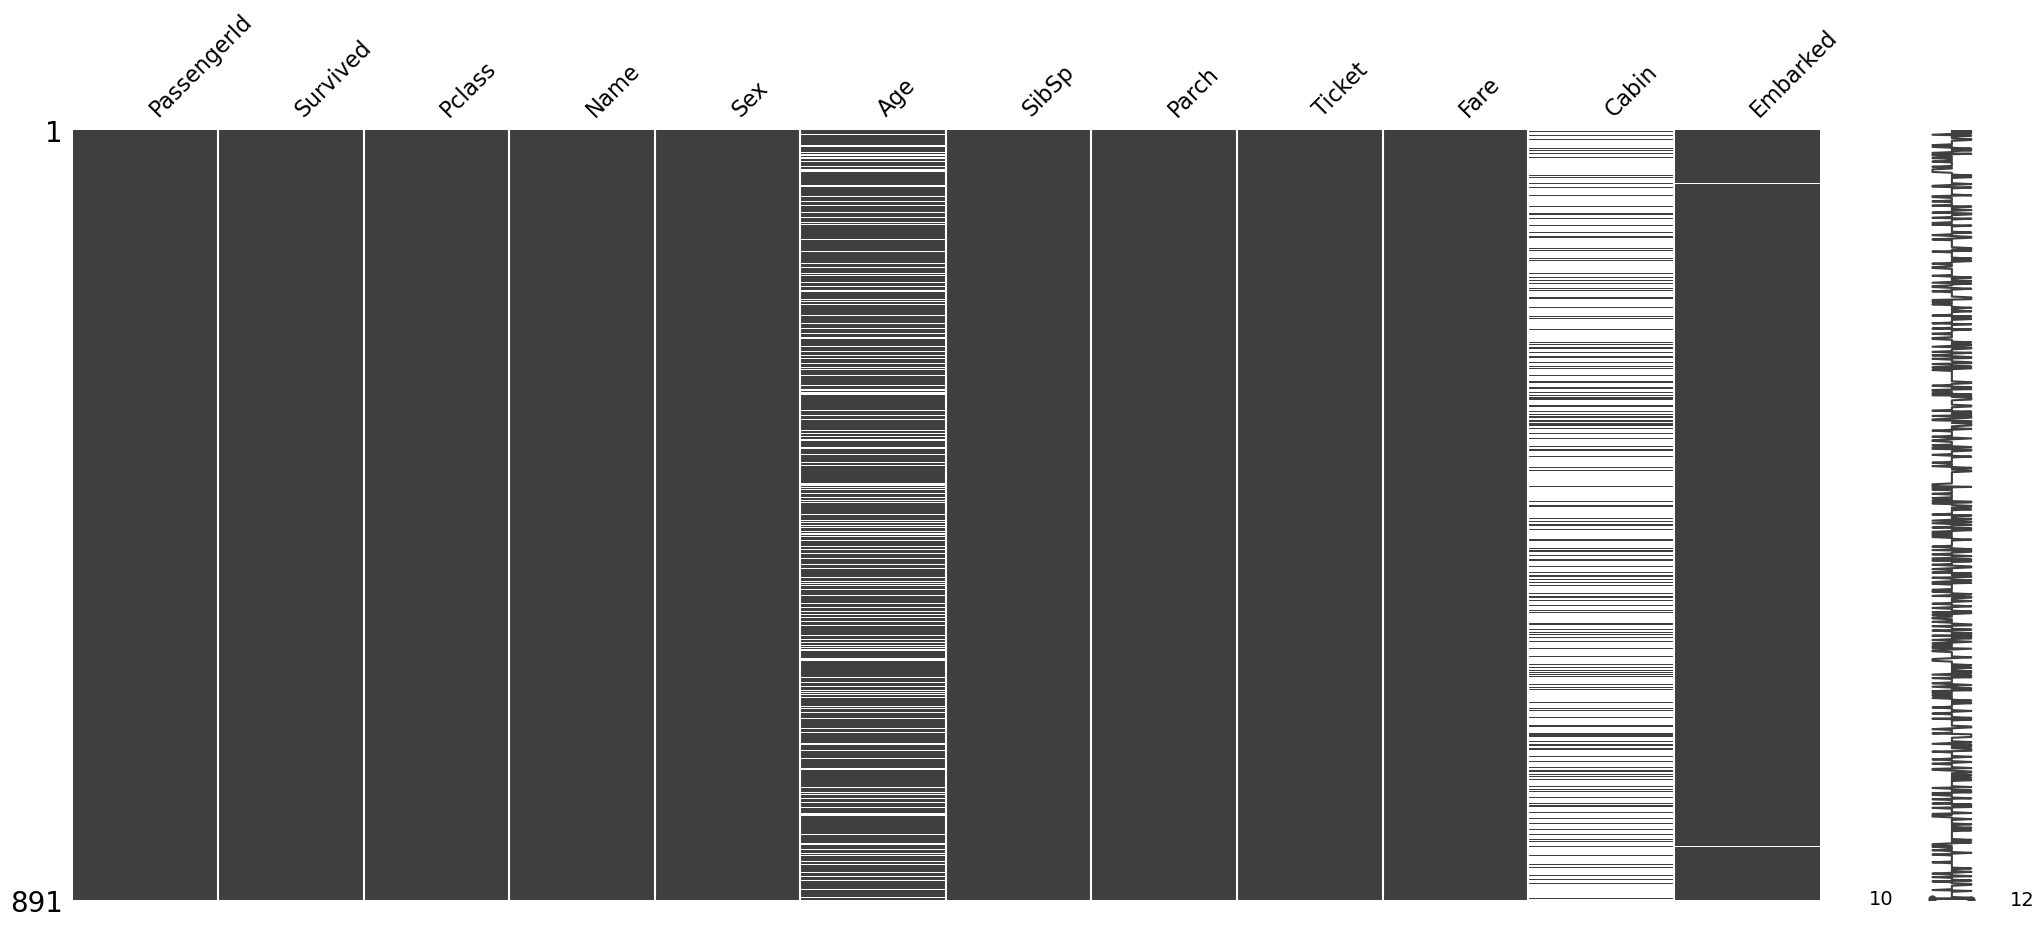

In [14]:
import missingno as msno
msno.matrix(df)

In [15]:
df['Age'].fillna(df['Age'].median(), inplace=True) # numeric featurelerde bulunan missing vakuları median ile doldurduk 

In [16]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True) # categoric featurelerde bulunan missing vakuları mod ile doldurduk 

In [17]:
df.drop(columns="Cabin", inplace=True) #  687 tane NaN value missing value vardır. bu sebeple drop ettik 

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<Axes: >

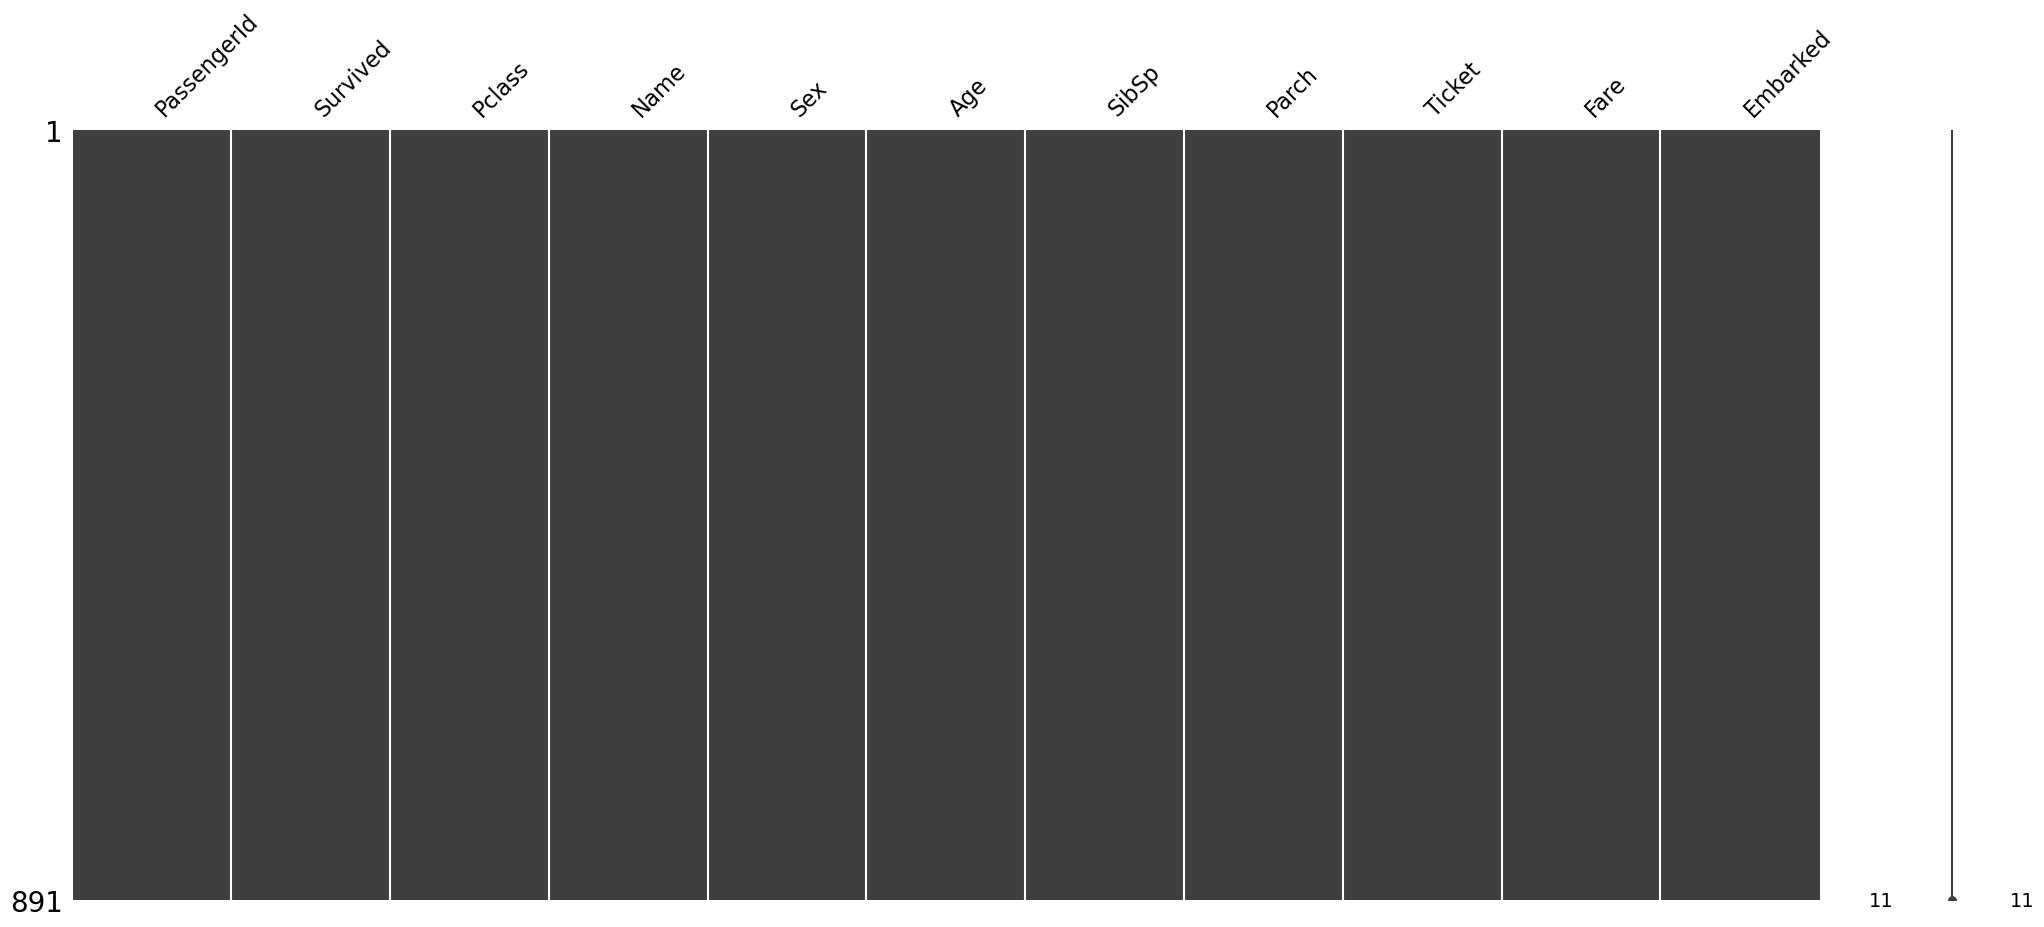

In [19]:
msno.matrix(df)

In [20]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [21]:
column_info(df_test)
# PassengerId : 418 tane unique değeri, her yolcu için benzersiz ID vardır. Model için anlamlı bilgi taşımaz.
# Pclass  : Yolcunun sosyal sınıfını temsil eden 3 tane sınıf vardır. 1 → Üst sınıf, 2 → Orta sınıf, 3 → Alt sınıf
# Name : 418 tane unique değeri vardır. Her isim benzersiz. 
# Sex : Çok güçlü bir kategorik değişken. male, female olarak iki unique değer vardır.
# Age : 86 tane NaN value missing value vardır. 88 tane unique değer vardır. Min: 0.17(2 aylık bebek), max :76 yaş  dağılım geniş aralıkta outlier olabilir.
# SibSp : 7 tane unique değeri vardır. Gemideki kardeş/eş sayısı.
# Parch : 8 tane unique değer vardır . Gemideki ebeveyn/çocuk sayısı.
# Ticket : 363 tane unique değeri vardır .Düzensiz formatta , çok fazla benzersiz değer.Yüksek kardinaliteye sahip.
# Fare : 169 tane unique değeri vardır .Dağılım sağa çarpık olabilir . Outlier içeriyor olabilir
# Cabin : 327 tane NaN value missing value vardır.
# Embarked : Biniş limanı bilgisidir. 3 tane unique değer ve 2 tane NaN value missing value vardır.

,Column_name,Data_Type,Count,NaN_Count,NaN_Percent,Unique_Count,Max_Value,Min_Value,Sample_Value
0,PassengerId,int64,418,0,0.000000,418,1309,892,1043
1,Pclass,int64,418,0,0.000000,3,3,1,3
2,Name,object,418,0,0.000000,418,no value,no value,"Klasen, Miss. Gertrud Emilia"
3,Sex,object,418,0,0.000000,2,no value,no value,male
4,Age,float64,418,86,20.574163,79,76.0,0.17,23.0
5,SibSp,int64,418,0,0.000000,7,8,0,0
6,Parch,int64,418,0,0.000000,8,9,0,0
7,Ticket,object,418,0,0.000000,363,no value,no value,F.C.C. 13534
8,Fare,float64,418,1,0.239234,169,512.3292,0.0,81.8583
9,Cabin,object,418,327,78.229665,76,no value,no value,B10


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<Axes: >

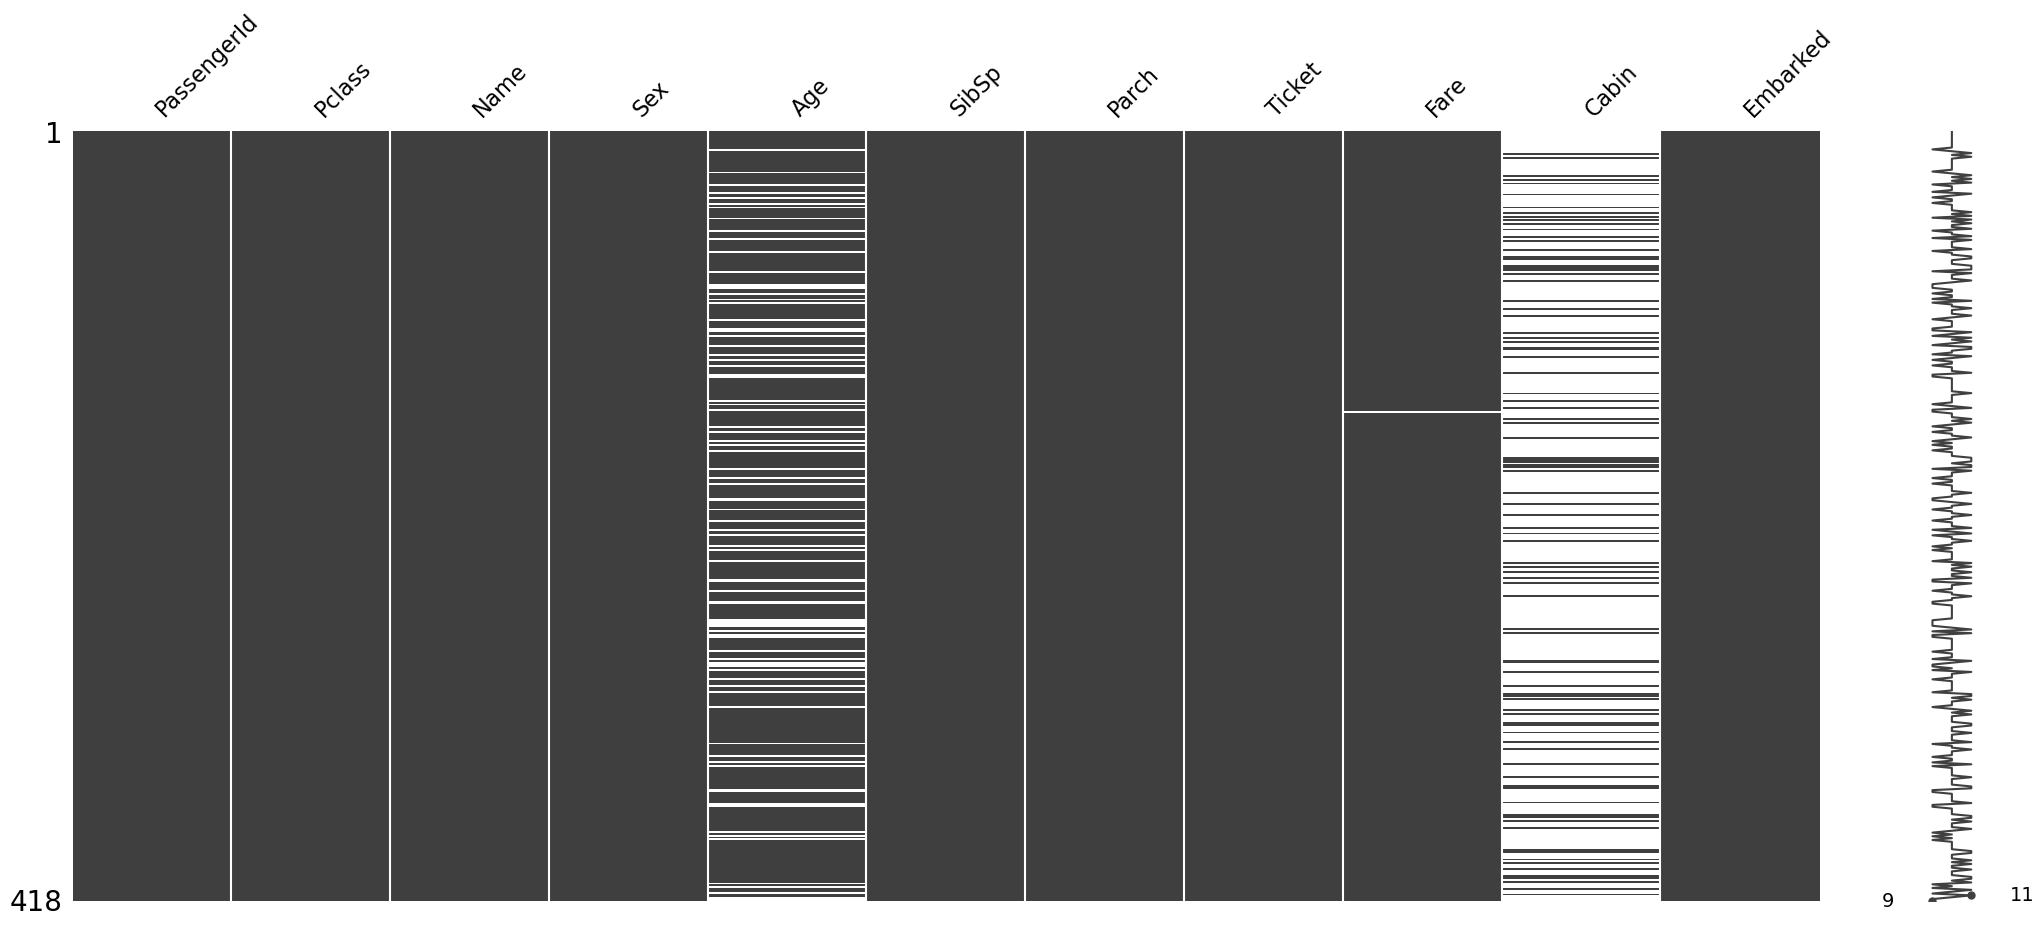

In [24]:
msno.matrix(df_test)

In [25]:
df_test['Age'].fillna(df_test['Age'].median(), inplace=True) # numeric featurelerde bulunan missing vakuları median ile doldurduk 

In [26]:
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True) # numeric featurelerde bulunan missing vakuları median ile doldurduk 

In [27]:
df_test['Embarked'].fillna(df_test['Embarked'].mode()[0], inplace=True) # categoric featurelerde bulunan missing vakuları mod ile doldurduk 

In [28]:
df_test.drop(columns="Cabin", inplace=True) #  687 tane NaN value missing value vardır. bu sebeple drop ettik 

In [29]:
df_test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<Axes: >

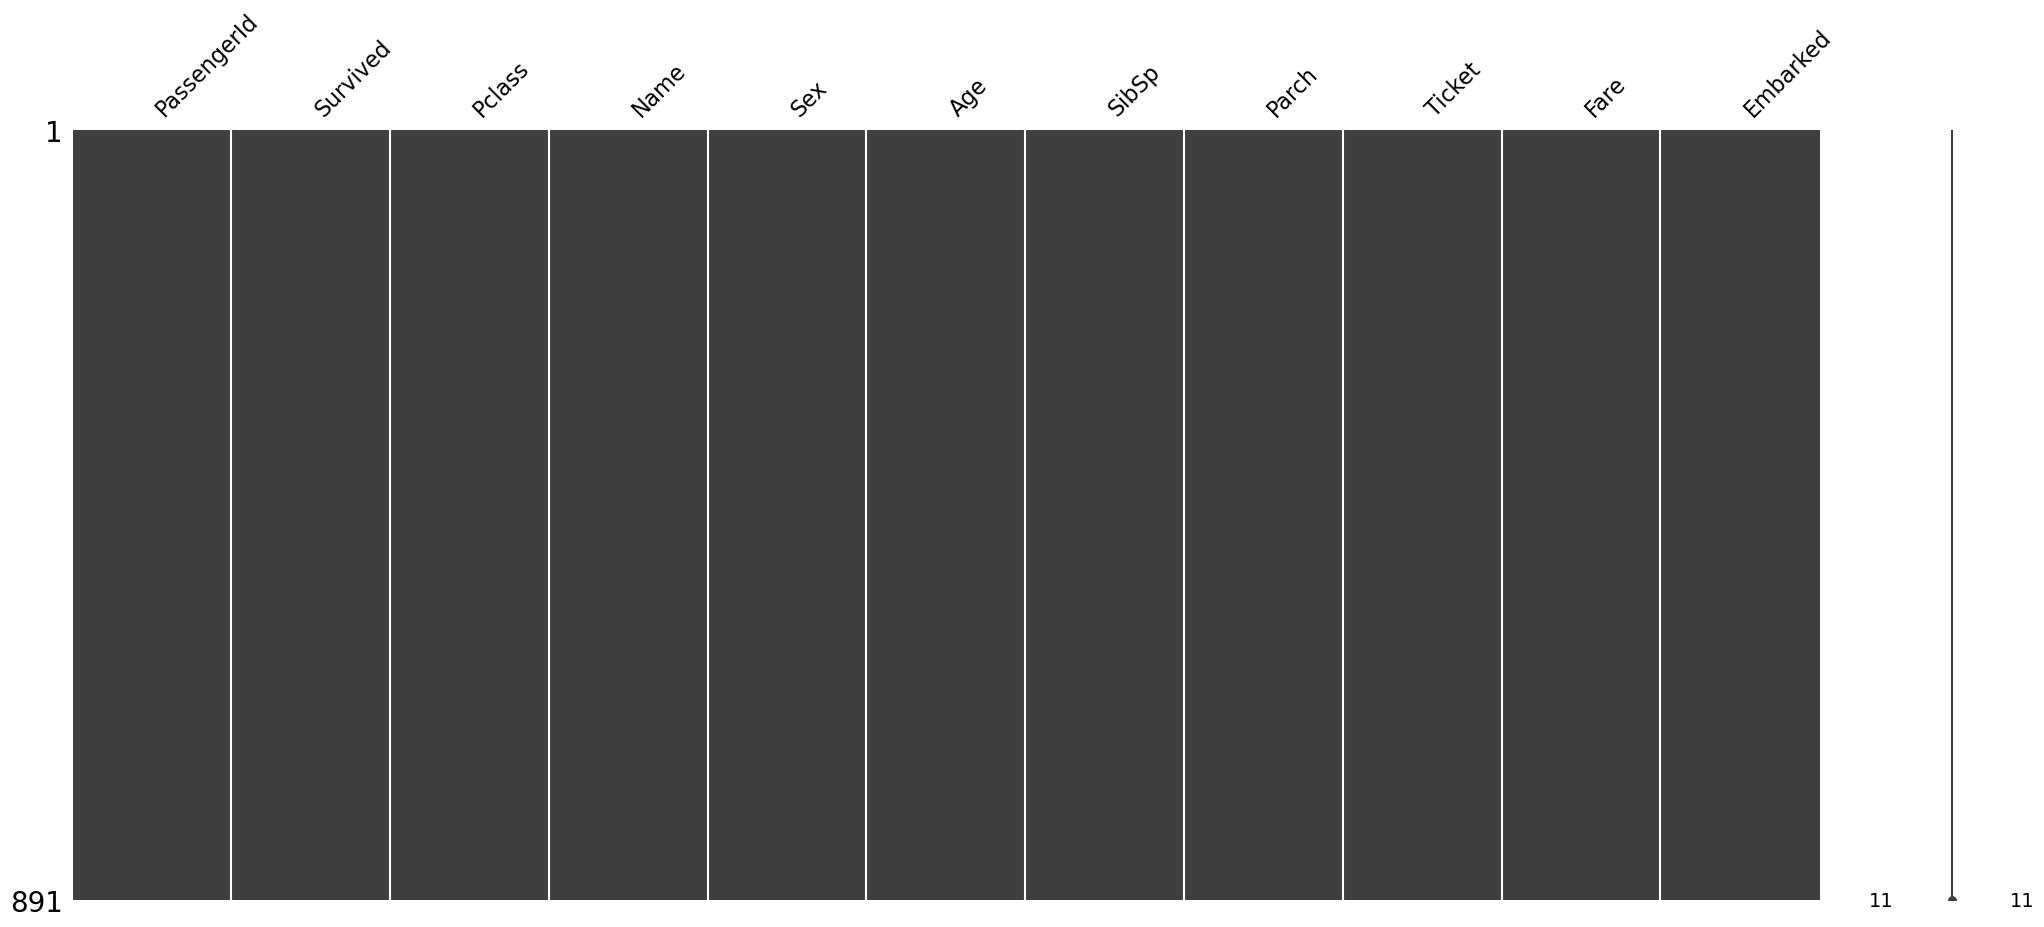

In [30]:
msno.matrix(df)

In [31]:
df.describe().T
#veri setindeki sayısal değişkenlerin istatistiksel analizi incelendiğinde, yolcuların büyük çoğunluğunun üçüncü sınıfta seyahat ettiği ve ortalama yaşın yaklaşık 30 olduğu görülmektedir.
#Survived değişkenine göre yolcuların yaklaşık %38’i hayatta kalmıştır.
#Age değişkeninde eksik veriler bulunduğu dikkat çekmektedir. Yaş dağılımı geniş bir aralığa sahip olup veri setinde bebeklerden yaşlı bireylere kadar farklı yaş grupları yer almaktadır.
#SibSp ve Parch değişkenlerinin medyan değerlerinin 0 olması, yolcuların çoğunun yalnız seyahat ettiğini göstermektedir. Ancak maksimum değerlerin yüksek olması bazı kalabalık aile gruplarının da bulunduğunu ortaya koymaktadır.
#Fare değişkeninde ortalamanın medyandan oldukça yüksek olması veri dağılımının sağa çarpık olduğunu ve yüksek ücretli biletlerden kaynaklanan aykırı değerlerin bulunduğunu göstermektedir

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [32]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

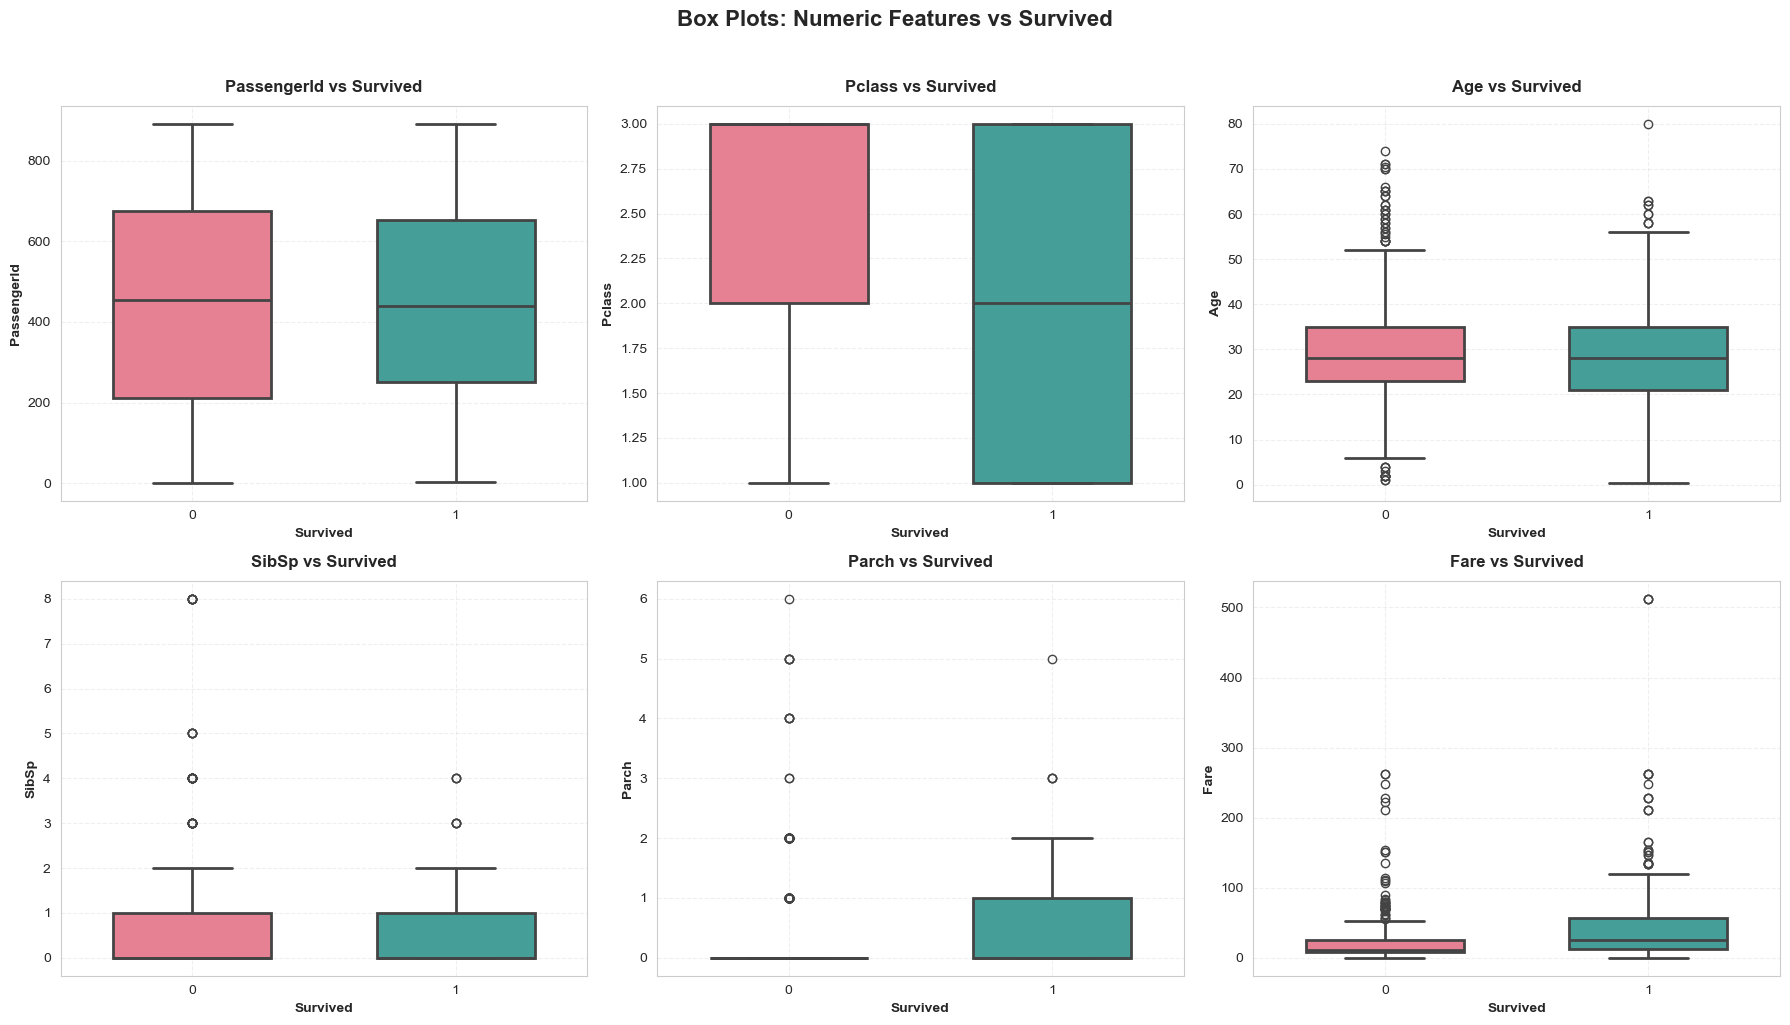

In [33]:
# =========================
# BOXPLOT
# =========================

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Target değişkeni çıkarılıyor
numeric_features = numeric_cols.drop('Survived')

# 6 feature için 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Color palette
colors = sns.color_palette("husl", len(df['Survived'].unique()))

# Boxplot çizimi
for idx, feature in enumerate(numeric_features):

    sns.boxplot(data=df, x='Survived', y=feature, ax=axes[idx], palette=colors, width=0.6, linewidth=2)

    axes[idx].set_title( f'{feature} vs Survived', fontsize=12, fontweight='bold', pad=10)

    axes[idx].set_xlabel('Survived', fontsize=10, fontweight='bold')

    axes[idx].set_ylabel( feature, fontsize=10, fontweight='bold')

    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle( 'Box Plots: Numeric Features vs Survived', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

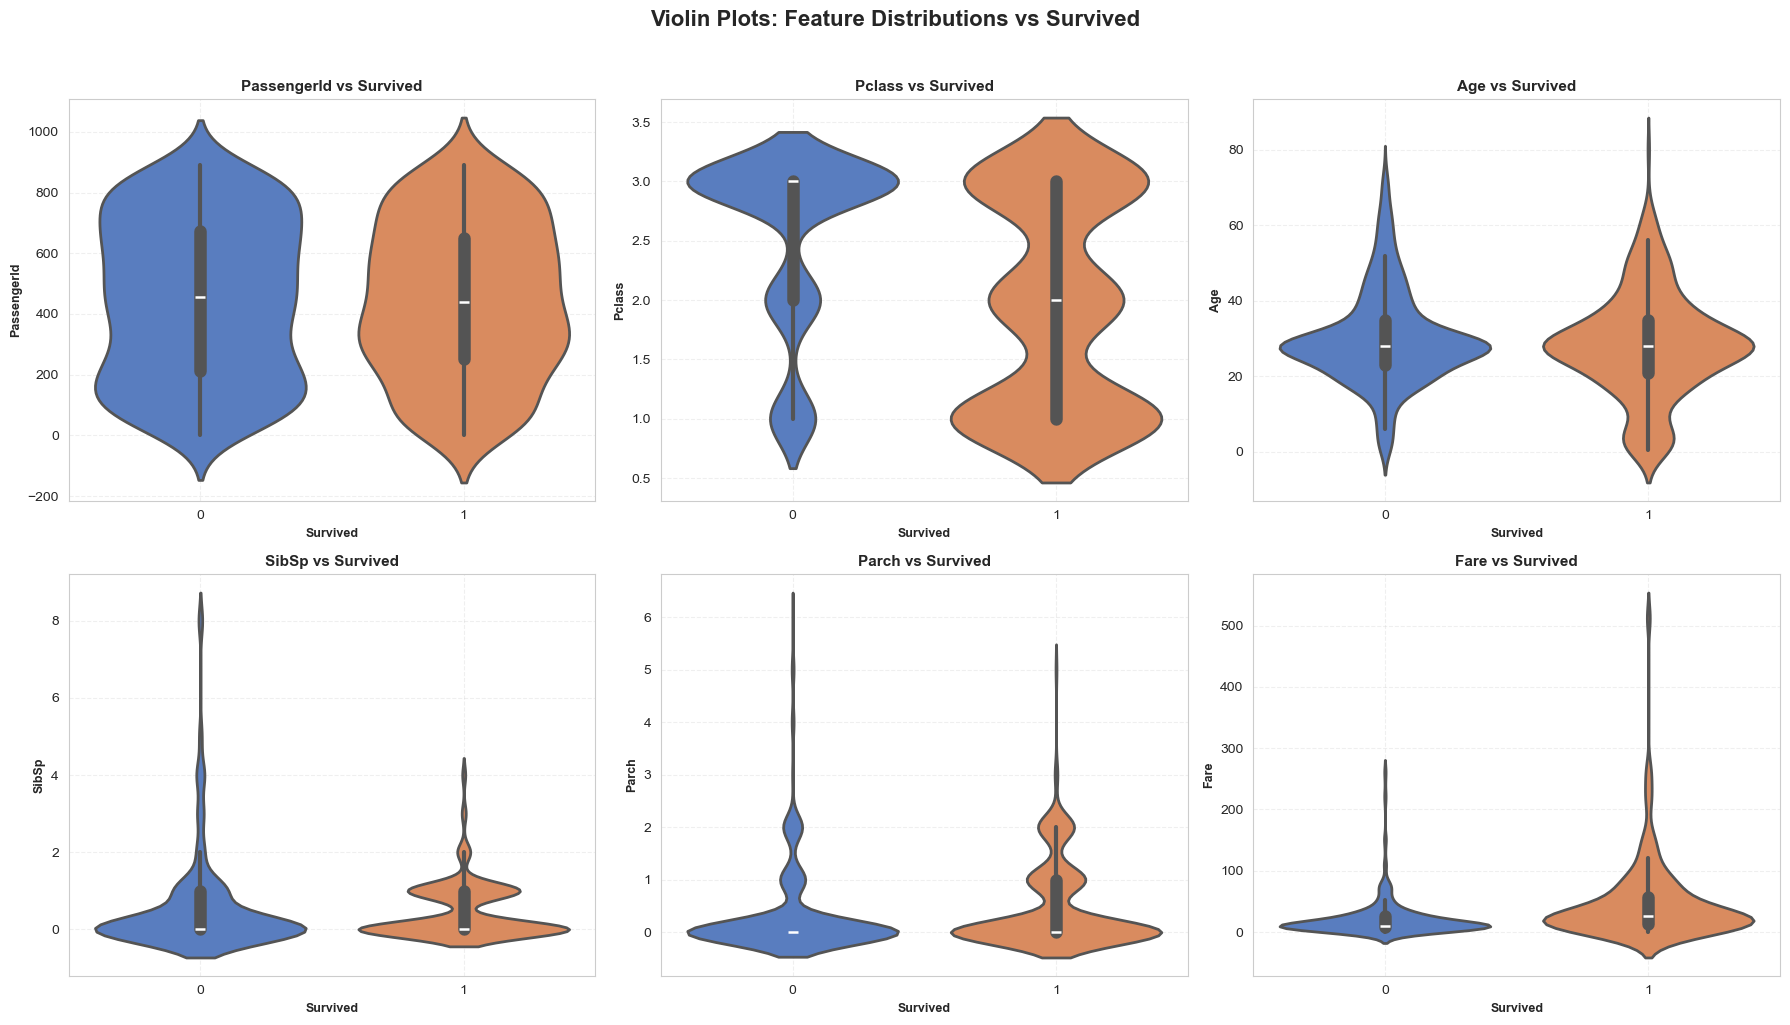

In [34]:
# =========================
# VIOLIN PLOT
# =========================

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Target değişkeni çıkarılıyor
numeric_features = numeric_cols.drop('Survived')

# 6 feature için 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Violin plot çizimi
for idx, feature in enumerate(numeric_features):

    sns.violinplot(data=df, x='Survived', y=feature, ax=axes[idx], palette="muted", inner="box", linewidth=2)

    axes[idx].set_title(f'{feature} vs Survived', fontsize=11, fontweight='bold')

    axes[idx].set_xlabel('Survived',fontsize=9,fontweight='bold')

    axes[idx].set_ylabel(feature,fontsize=9, fontweight='bold')

    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Violin Plots: Feature Distributions vs Survived', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

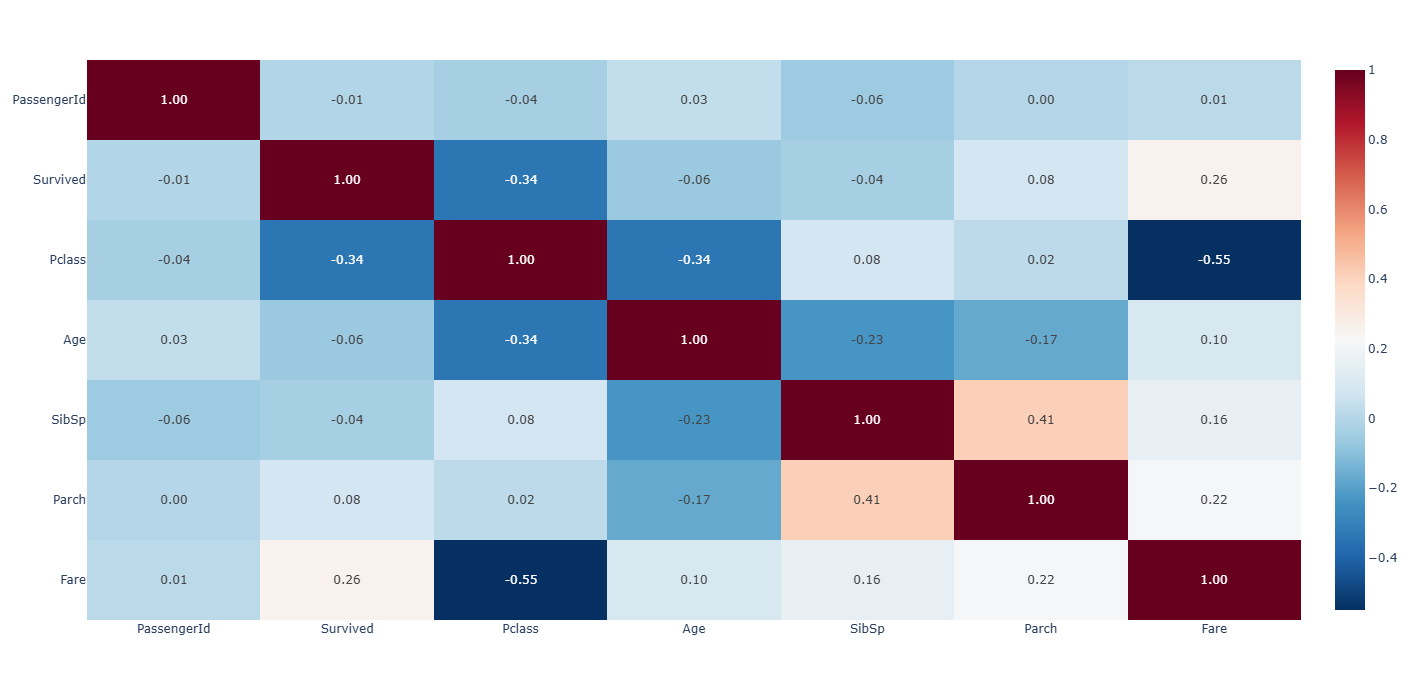

In [35]:
import plotly.express as px

corr_matrix = df.select_dtypes(include=['number']).corr()

fig = px.imshow(corr_matrix,
                text_auto='.2f',
                aspect="auto",
                color_continuous_scale='RdBu_r'
                )

fig.update_layout(width=800, height=700)

fig.show()

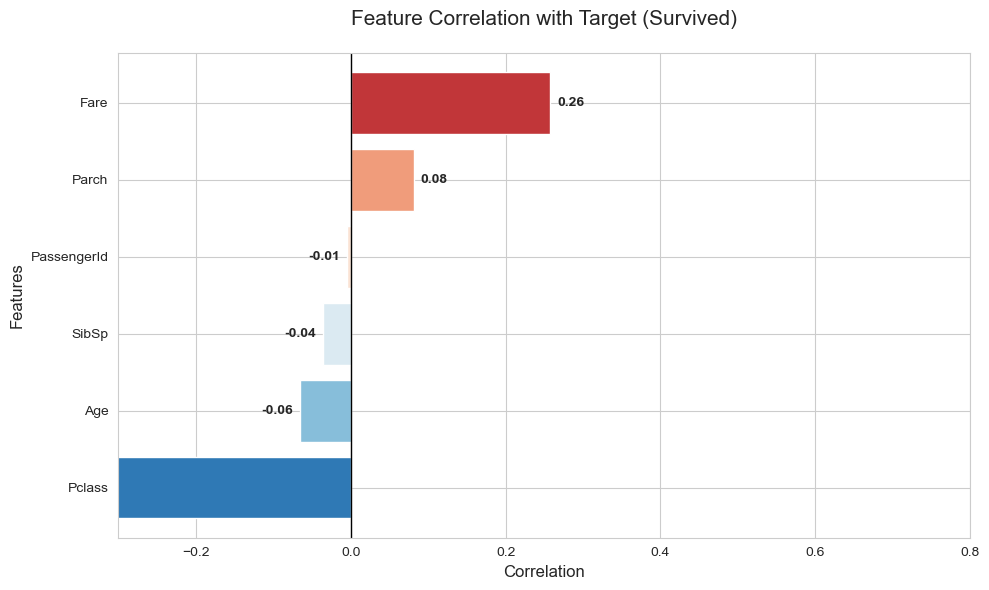

In [36]:
plt.figure(figsize=(10, 6))

sns.set_style("whitegrid")

# Sadece sayısal sütunlarla korelasyon hesaplama
correlations = ( df.select_dtypes(include=['number']).corr()["Survived"].drop("Survived").sort_values())

# Renk paleti
colors = sns.color_palette("RdBu_r", len(correlations))

# Grafik
ax = correlations.plot(kind="barh", color=colors, width=0.8)

# Değer etiketleri
ax.bar_label(ax.containers[0],fmt="%.2f", padding=5,fontweight='bold')

# Başlık ve eksenler
plt.title( "Feature Correlation with Target (Survived)", fontsize=15, pad=20)

plt.xlabel("Correlation", fontsize=12)
plt.ylabel("Features", fontsize=12)

# 0 çizgisi
plt.axvline(0, color='black', linewidth=1)

# X ekseni sınırı
plt.xlim(-0.3, 0.8)

plt.tight_layout()
plt.show()

In [37]:
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [38]:
cat_features = df.select_dtypes(include="object").columns
cat_features # encode işlemi yapacağımız için kategorik verileri kontrol ederiz 

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [39]:
unique_values(df, cat_features)

Column: Name
------------------------------
Unique Values (891): ['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima' 'Fynney, Mr. Joseph J' 'Beesley, Mr. Lawrence'
 'McGowan, Miss. Anna "Annie"' 'Sloper, Mr. William Thompson'
 'Palsson, Miss. Torborg Danira'
 'Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)'
 'Emir, Mr. Farred Chehab' 'Fortune,

In [40]:
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

# Veri eda sürecinde PassengerId, Name ve Ticket değişkenleri modelleme aşamasından çıkarılmıştır. 
# PassengerId yalnızca benzersiz kimlik bilgisi içerdiği için tahminleme açısından anlamlı bilgi sağlamamaktadır. 
# Name değişkeni yüksek kardinaliteye sahip olduğundan doğrudan modele dahil edilmemiş,drop edilmiştir. 
# Ticket değişkeni ise düzensiz ve çok fazla benzersiz kategori içerdiği için model performansına katkısı sınırlı görülmüş ve veri setinden çıkarılmıştır. Bu işlem ile veri seti sadeleştirilmiş ve modelin gereksiz karmaşıklığı azaltılmıştır.


In [41]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [42]:
df.shape

(891, 8)

In [43]:
df_test.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

# Veri eda sürecinde train dataya ne uygulandıysa aynısı test dataya uygulanmıştır. PassengerId, Name ve Ticket değişkenleri modelleme aşamasından çıkarılmıştır. 

In [44]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [45]:
df_test.shape

(418, 7)

In [46]:
num_features_test = df_test.select_dtypes(include=["int64", "float64"]).columns
num_features_test

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [47]:
cat_features_test = df_test.select_dtypes(include="object").columns
cat_features_test

Index(['Sex', 'Embarked'], dtype='object')

In [48]:
num_features = df.select_dtypes(include=["int64", "float64"]).columns
num_features 

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [49]:
cat_features = df.select_dtypes(include="object").columns
cat_features 

Index(['Sex', 'Embarked'], dtype='object')

In [50]:
cat_features = df.select_dtypes(include="object").columns

for col in cat_features:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== Sex =====
Sex
male      577
female    314
Name: count, dtype: int64

===== Embarked =====
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


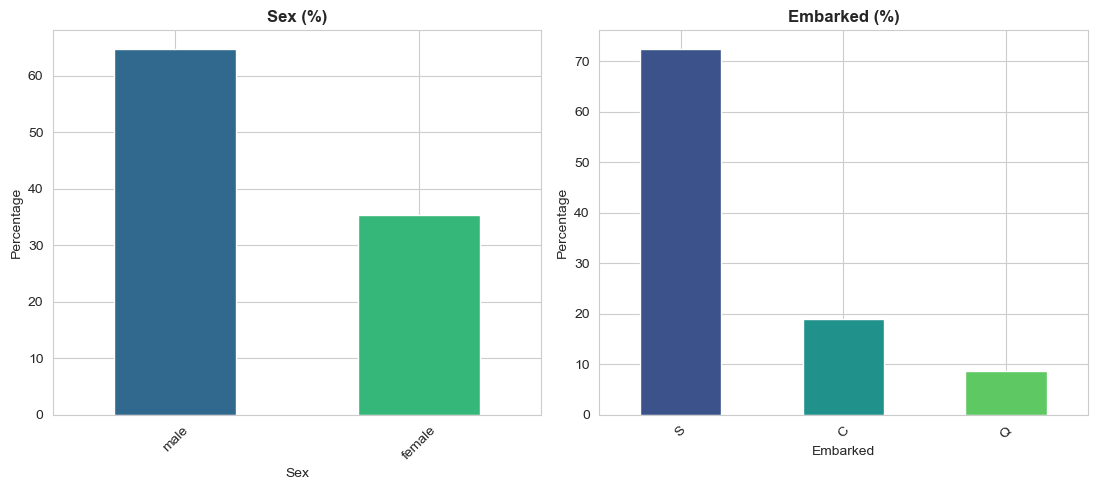

In [51]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = len(cat_features)
n_rows = math.ceil(n_cols / 4)  # 4 sütun sabit

fig, axes = plt.subplots(n_rows, 4, figsize=(22, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    
    (df[col].value_counts(normalize=True)*100).plot(
        kind="bar",
        ax=axes[i],
        color=sns.color_palette("viridis", len(df[col].unique()))
    )
    
    axes[i].set_title(f"{col} (%)", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Percentage", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

# boş eksenleri sil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Train | Test Split

In [52]:
df["Survived"].value_counts()

#Survived hedef değişkeninin dağılımı incelendiğinde veri setinin tamamen dengeli olmadığı görülmektedir. Veri setindeki 891 yolcunun 549’u (%61.6) hayatını kaybetmiş (0), 342’si (%38.4) ise hayatta kalmıştır (1). 
# Bu durum orta seviyede bir class imbalance (sınıf dengesizliği) olduğunu göstermektedir. Veri setindeki çoğunluk sınıfı “hayatta kalmayanlar”dır.

Survived
0    549
1    342
Name: count, dtype: int64

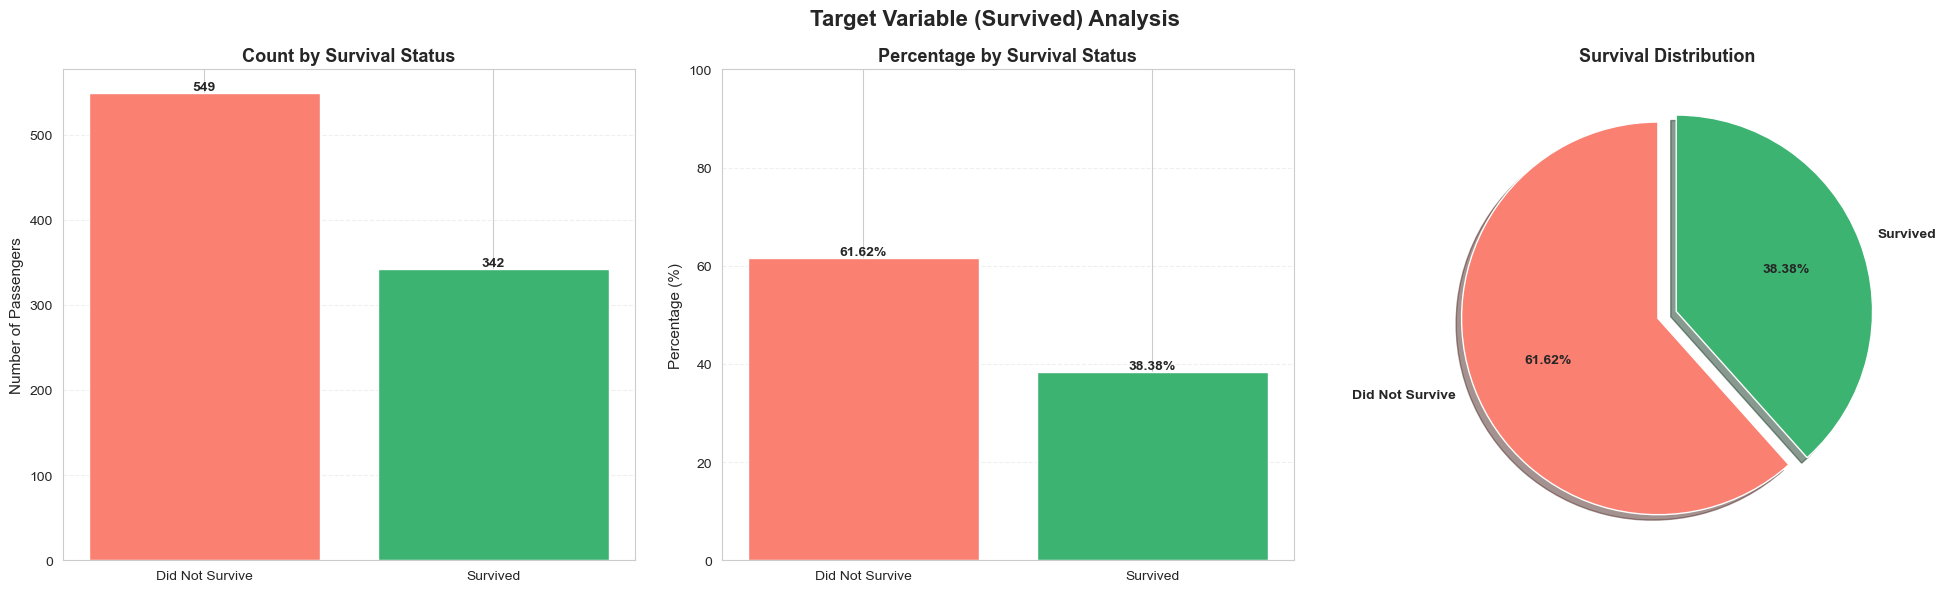

In [53]:
# Target değişkeni
target_col = "Survived"

# Count ve percentage
Survived_counts = df[target_col].value_counts().sort_index()
Survived_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

# Label isimleri
labels = ['Did Not Survive', 'Survived']

# Renkler
colors = ['salmon', 'mediumseagreen']

# Grafik
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# 1. Count Plot

bars = axes[0].bar( labels, Survived_counts.values, color=colors )

axes[0].set_title('Count by Survival Status', fontsize=13, fontweight='bold')

axes[0].set_ylabel('Number of Passengers', fontsize=11)

axes[0].grid( True, alpha=0.3, axis='y', linestyle='--')

# Değer yazıları
for bar in bars:

    height = bar.get_height()

    axes[0].text( bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontweight='bold')


# 2. Percentage Plot

bars2 = axes[1].bar(labels, Survived_pct.values, color=colors)

axes[1].set_title('Percentage by Survival Status', fontsize=13, fontweight='bold')

axes[1].set_ylabel('Percentage (%)', fontsize=11)

axes[1].set_ylim(0, 100)

axes[1].grid( True, alpha=0.3, axis='y', linestyle='--')

# Yüzde yazıları
for bar in bars2:

    height = bar.get_height()

    axes[1].text( bar.get_x() + bar.get_width()/2, height, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# 3. Pie Chart

wedges, texts, autotexts = axes[2].pie(Survived_counts.values,
                                       labels=labels, 
                                       autopct='%1.2f%%', 
                                       colors=colors, startangle=90, 
                                       explode=[0.05, 0.05], 
                                       shadow=True,
                                       textprops={'fontsize': 10,
                                                  'fontweight': 'bold'})

axes[2].set_title('Survival Distribution', fontsize=13, fontweight='bold')

# Genel başlık
plt.suptitle('Target Variable (Survived) Analysis', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [54]:
X = df.drop(columns=[ "Survived"])
y=  df["Survived"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) # inbalance data olduğu için  stratify=y kullanıldı 

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

num_features = X.select_dtypes(include="number").columns
cat_features = X.select_dtypes(exclude="number").columns

preprocessor = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_features),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
                ], 
                verbose_feature_names_out=False ).set_output(transform="pandas")

In [57]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
pipeline.set_output(transform="pandas") #Bu komut, pipeline'ın çıktı olarak NumPy dizisi yerine DataFrame döndürmesini sağlar.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Sex', 'Embarked'], dtype='object'))],
                                   verbose_feature_names_out=False))])

In [58]:
X_train = pipeline.fit_transform(X_train)  #  train setinde ayrılan X_train set (train datasının %80 kısmı )  fit edilir. 
X_valid = pipeline.transform(X_valid)   # train setinde ayrılan ve model fit edildikten sonra predic için kullanılacak olan Validation Set(train datasının %20 kısmı ) transform edilir. 
X_test = df_test # Kaggle Titanic verisinde train.csv → model eğitimi ,test.csv → tahmin (label yok). tahmin için kullanılacak veri seti df_test -> test.csv atama yapıldı 
X_test =  pipeline.transform(X_test)

In [59]:
print("Transformed Training Data:")
print(X_train)
print("Transformed Validation Data:")
print(X_valid)
print("Transformed Test Data:")
print(X_test)

Transformed Training Data:
       Pclass       Age     SibSp     Parch       Fare  Sex_female  Sex_male  \
692  0.829568 -0.112078 -0.465084 -0.466183   0.513812         0.0       1.0   
481 -0.370945 -0.112078 -0.465084 -0.466183  -0.662563         0.0       1.0   
527 -1.571457 -0.112078 -0.465084 -0.466183   3.955399         0.0       1.0   
855  0.829568 -0.879807 -0.465084  0.727782  -0.467874         1.0       0.0   
801 -0.370945  0.118241  0.478335  0.727782  -0.115977         1.0       0.0   
..        ...       ...       ...       ...        ...         ...       ...   
359  0.829568 -0.112078 -0.465084 -0.466183  -0.498500         1.0       0.0   
258 -1.571457  0.425333 -0.465084 -0.466183  10.005329         1.0       0.0   
736  0.829568  1.423382  0.478335  3.115713   0.053205         1.0       0.0   
462 -1.571457  1.346609 -0.465084 -0.466183   0.139097         0.0       1.0   
507 -1.571457 -0.112078 -0.465084 -0.466183  -0.109730         0.0       1.0   

     Embarke

In [60]:
print(X_train.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [61]:
print(X_valid.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [62]:
print(X_test.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


## Modelling | Model Performance

### AdaBoost Modelling and Model Performance

In [63]:
def eval_metric(model, X_train, y_train, X_valid, y_valid):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_valid)
    
    print("Valid_Test_Set")
    print(confusion_matrix(y_valid, y_pred))
    print(classification_report(y_valid, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [64]:
ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)  # default n_estimators=50

In [65]:
ada_model.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [66]:
eval_metric(ada_model, X_train, y_train, X_valid, y_valid)

#Doğruluk (Accuracy) Karşılaştırması: Modelin Eğitim Setinde (Train Set) %83, Valid test setinde  (Valid Set) ise %78 doğruluk oranına ulaşmıştır. 
# Eğitim ve test setleri arasındaki %5'lik fark, modelin veriyi ezberlemek yerine "genelleme" (generalization) yapabildiğini ve aşırı öğrenmeden (overfitting) büyük ölçüde kaçındığını göstermektedir
# Precision (Kesinlik - 0.75): Model bir yolcu için "hayatta kaldı" dediğinde bu tahminin doğruluk payı %75'tir.
# Recall (Duyarlılık - 0.65): Gerçekten hayatta kalan yolcuların %65'i model tarafından doğru yakalanmıştır. Bir felaket analizi senaryosunda bu metrik kritiktir; 
# çünkü hayatta kalanları kaçırmamanın (False Negative sayısını azaltmanın) maliyeti daha yüksektir.
# F1-Score (0.70): Hassasiyet ve duyarlılık arasındaki dengeli başarıyı temsil eden bu değer, modelin pozitif sınıfı tahmin etmede tutarlı bir performans sergilediğini göstermektedir
# Model, hayatını kaybeden 110 yolcunun 95'ini (%86 Recall) ve hayatta kalan 69 yolcunun 45'ini (%65 Recall) tam doğrulukla tespit etmiştir.

Valid_Test_Set
[[95 15]
 [24 45]]
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179


Train_Set
[[387  52]
 [ 70 203]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       439
           1       0.80      0.74      0.77       273

    accuracy                           0.83       712
   macro avg       0.82      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712



In [67]:
model = AdaBoostClassifier(n_estimators=50, random_state=42)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=["accuracy", "precision", "recall", "f1"],
                        cv=10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index=range(1, 11))
df_scores.mean()[2:]

test_accuracy      0.804812
train_accuracy     0.813673
test_precision     0.750771
train_precision    0.760165
test_recall        0.747619
train_recall       0.753338
test_f1            0.744117
train_f1           0.756204
dtype: float64

In [68]:
model = AdaBoostClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 150, 200, 250],  
    "learning_rate": [ 0.1, 0.5, 0.8, 1],
    "algorithm": ["SAMME"]
}

In [69]:
ada_grid_model = GridSearchCV(model, param_grid, cv=5, scoring= "f1")

In [70]:
ada_grid_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'algorithm': ['SAMME'],
                         'learning_rate': [0.1, 0.5, 0.8, 1],
                         'n_estimators': [100, 150, 200, 250]},
             scoring='f1')

In [71]:
ada_grid_model.best_params_

{'algorithm': 'SAMME', 'learning_rate': 0.8, 'n_estimators': 200}

In [72]:
ada_grid_model.best_estimator_

AdaBoostClassifier(algorithm='SAMME', learning_rate=0.8, n_estimators=200,
                   random_state=42)

In [73]:
ada_grid_model.best_score_

np.float64(0.7555142352321322)

In [74]:
y_pred = ada_grid_model.predict(X_valid)
y_pred_proba = ada_grid_model.predict_proba(X_valid)

ada_accuracy = accuracy_score(y_valid, y_pred)
ada_precision = precision_score(y_valid, y_pred)
ada_recall = recall_score( y_valid, y_pred)
ada_f1 = f1_score(y_valid, y_pred)
ada_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(ada_grid_model, X_train, y_train, X_valid, y_valid)

# Doğruluk (Accuracy) Dengesi: Model  Eğitim Setinde %82, Valid Test Setinde (Valid Set) ise %80 doğruluk oranına ulaşmıştır.Overfittig yoktur. 
# Eğitim ve test skorları arasındaki farkın sadece %2 olması, modelin mükemmel bir genelleme (generalization) kabiliyetine sahip olduğunu gösterir. 
# Precision (Kesinlik - 0.75): Model bir yolcuya "sağ kaldı" dediğinde, bu tahminin doğruluk payı %73'tür.
# Recall (Duyarlılık - 0.71): Gerçekten hayatta kalan yolcuların %71'i model tarafından doğru tespit edilmiştir.
# F1-Score (0.73): Hassasiyet ve duyarlılık arasındaki dengeli başarıyı temsil eden bu skor, GridSearchCV ile yapılan hiperparametre optimizasyonunun modelin karar sınırlarını ne kadar tutarlı hale getirdiğini kanıtlamaktadır
# Model, hayatını kaybeden 110 yolcunun 94'sini ve hayatta kalan 69 yolcunun 49'unu başarıyla tahmin etmiştir.

Valid_Test_Set
[[94 16]
 [20 49]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Train_Set
[[374  65]
 [ 64 209]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       439
           1       0.76      0.77      0.76       273

    accuracy                           0.82       712
   macro avg       0.81      0.81      0.81       712
weighted avg       0.82      0.82      0.82       712



#### Feature_Importances AdaBoostClassifier

In [75]:
model = AdaBoostClassifier(algorithm='SAMME', learning_rate=0.8, n_estimators=200, random_state=42)
model.fit(X_train, y_train)
model.feature_importances_

array([0.07779153, 0.19559137, 0.11638195, 0.0719963 , 0.38884076,
       0.0187748 , 0.10593649, 0.        , 0.        , 0.02468679])

In [76]:
feature_names = preprocessor.get_feature_names_out()

ada_imp_feats = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

ada_imp_feats
#Sosyo-Ekonomik Göstergelerin Baskınlığı (Fare & Pclass)
    #Fare (Bilet Ücreti - %36.7): Modelin en güçlü tahminleyicisi açık ara bilet ücretidir. İstatistiksel bir bakış açısıyla bu durum, hayatta kalma olasılığının ekonomik güçle doğrudan korelasyon gösterdiğini kanıtlamaktadır.
    #Pclass (Yolcu Sınıfı - %9.5): Bilet ücretiyle birlikte değerlendirildiğinde, yolcuların gemideki konumu ve sınıfsal statüsünün model kararlarında yaklaşık %46'lık bir ağırlığa sahip olduğu görülmektedir.
#Demografik Faktörlerin Etkisi (Age & Sex)
    # Age (Yaş - %19.4): Yaş, modelin en önemli ikinci değişkenidir. "Önce kadınlar ve çocuklar" ilkesinin model tarafından sayısal olarak öğrenildiğini ve yaş değişkeninin hayatta kalma tahmininde kritik bir eşik değer oluşturduğunu göstermektedir.
    # Cinsiyet (Sex_male: %12.1, Sex_female: %5.1): Cinsiyet değişkenleri toplamda %17'nin üzerinde bir öneme sahiptir. 
    # Özellikle Sex_male değişkeninin yüksek ağırlığı, modelin "erkek" olmanın hayatta kalma şansı üzerindeki negatif etkisini (cezalandırma katsayısı gibi) güçlü bir şekilde kullandığını işaret eder.
#Aile Yapısı ve Sosyal Bağlar (SibSp & Parch)
    #SibSp (%8.3) ve Parch (%6.6): Gemideki aile üyelerinin sayısı, tahminde toplam %15'lik bir paya sahiptir. 
# Coğrafi Verilerin Etkisizliği (Embarked)
    #Embarked_S (%2.1), Embarked_C (%0) ve Embarked_Q (%0): Yolcuların gemiye biniş limanlarının hayatta kalma üzerinde neredeyse hiç etkisi olmadığı görülmektedir. 
# Model, hayatta kalma durumunu tahmin ederken "Socio-Economic Status" (Sosyo-Ekonomik Durum) ve "Demographics" (Demografi) eksenli bir mantık kurgulamıştır. 

,feature,importance
4,Fare,0.388841
1,Age,0.195591
2,SibSp,0.116382
6,Sex_male,0.105936
0,Pclass,0.077792
3,Parch,0.071996
9,Embarked_S,0.024687
5,Sex_female,0.018775
7,Embarked_C,0.000000
8,Embarked_Q,0.000000


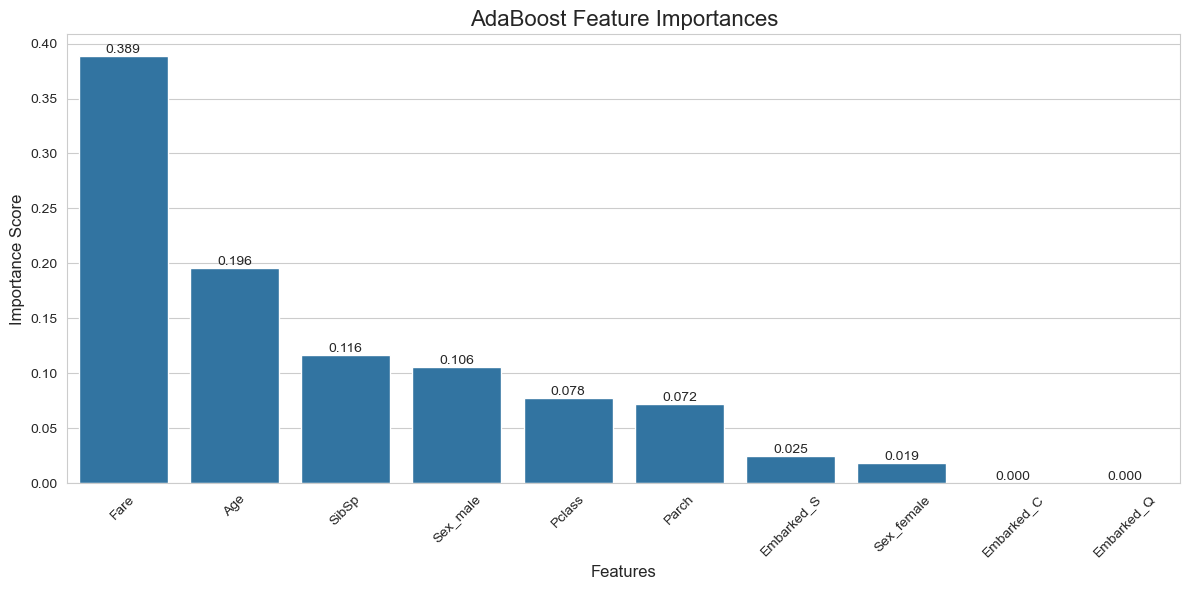

In [77]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=ada_imp_feats, x="feature", y="importance")

# Bar üstüne değer yazdırma
ax.bar_label(ax.containers[0], fmt="%.3f")

# Başlık
plt.title("AdaBoost Feature Importances", fontsize=16)

# Eksen isimleri
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# X label döndürme
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

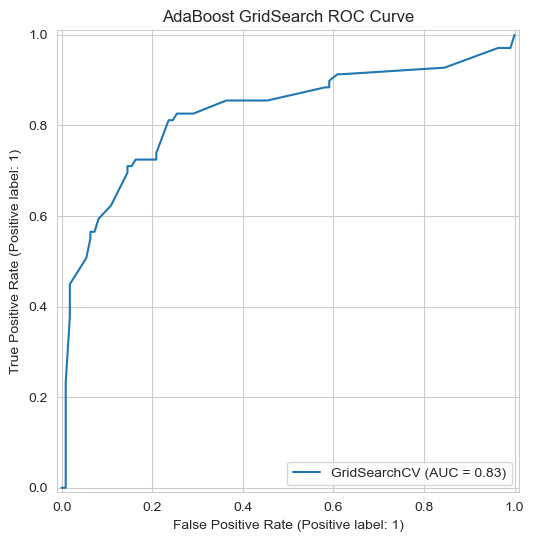

In [78]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(ada_grid_model, X_valid, y_valid)

plt.title(f"AdaBoost GridSearch ROC Curve")
plt.show()

### Gradient Boosting Modelling and Model Performance

In [79]:
grad_model = GradientBoostingClassifier(random_state=42)

In [80]:
grad_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [81]:
eval_metric(grad_model, X_train, y_train, X_valid, y_valid)

# Doğruluk (Accuracy) Değerlendirmesi: Model Eğitim Setinde %90, Valid_test Setinde (Valid Set) %80 doğruluk oranına ulaşmıştır.
# Eğitim ve test setleri arasındaki %10'luk fark, Gradient Boosting gibi güçlü algoritmalar için beklenen bir durumdur ancak modelin bir miktar "aşırı öğrenme" (overfitting) eğiliminde olduğunu gösterir. 
# Precision (Kesinlik - 0.79): Model "hayatta kaldı" tahmini yaptığında %79 oranında haklı çıkmaktadır. Bu, modelin yanlış pozitif (hayatta kalmadığı halde kaldı denilenler) hata payının düşük olduğunu gösterir.
#Recall (Duyarlılık - 0.65): Gerçekten hayatta kalan yolcuların %65'i doğru tespit edilmiştir. Bu metrik,en çok gelişime açık alanıdır; çünkü hayatta kalan 69 kişiden 24'ü model tarafından "öldü" (False Negative) olarak hatalı sınıflandırılmıştır.
# F1-Score (0.71): Hassasiyet ve duyarlılık arasındaki dengeyi gösteren bu skor, baz model için makul bir başlangıç seviyesidir.
# Confusion Matrix Analizi Doğrulama setindeki (179 yolcu) hata dağılımı:Doğru Tahminler: 98 kişi "öldü", 45 kişi "sağ kaldı" olarak tam doğrulukla tahmin edilmiştir.

Valid_Test_Set
[[98 12]
 [24 45]]
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179


Train_Set
[[420  19]
 [ 50 223]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       439
           1       0.92      0.82      0.87       273

    accuracy                           0.90       712
   macro avg       0.91      0.89      0.90       712
weighted avg       0.90      0.90      0.90       712



In [82]:
model = GradientBoostingClassifier(random_state=42)

scores = cross_validate(model, X_train, y_train, scoring = ['accuracy', 'precision','recall',
                                                                   'f1', 'roc_auc'], cv = 10, return_train_score=True)
df_scores = pd.DataFrame(scores, index = range(1, 11))
df_scores.mean()[2:]

test_accuracy      0.828775
train_accuracy     0.911986
test_precision     0.820863
train_precision    0.933252
test_recall        0.707407
train_recall       0.829876
test_f1            0.753760
train_f1           0.878482
test_roc_auc       0.878480
train_roc_auc      0.960271
dtype: float64

In [83]:
gb_model = GradientBoostingClassifier(random_state = 42)

param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 1.0],
    "max_features": ["sqrt", "log2", None]
}

In [84]:
gb_grid = GridSearchCV(gb_model,
                       param_grid,
                       scoring="f1",
                       verbose=2,
                       n_jobs=-1,
                       return_train_score=True).fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


In [85]:
gb_grid.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'max_features': None,
 'n_estimators': 200,
 'subsample': 0.8}

In [86]:
gb_grid.best_estimator_

GradientBoostingClassifier(n_estimators=200, random_state=42, subsample=0.8)

In [87]:
gb_grid.best_score_

np.float64(0.7579264914024622)

In [88]:
y_pred = gb_grid.predict(X_valid)
y_pred_proba = gb_grid.predict_proba(X_valid)

gb_accuracy = accuracy_score(y_valid, y_pred)
gb_precision= precision_score(y_valid, y_pred)
gb_recall = recall_score( y_valid, y_pred)
gb_f1 = f1_score(y_valid, y_pred)
gb_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(gb_grid, X_train, y_train, X_valid, y_valid)

#Baz modelin %80 olan doğrulama (valid) başarısı, GridSearchCV optimizasyonu sonrası %81'e yükselmiştir.
#Eğitim setindeki başarının %93 seviyesine çıkması, modelin verideki karmaşık desenleri (cinsiyet, yaş ve bilet ücreti etkileşimleri gibi) çok daha hassas bir şekilde öğrendiğini gösterir.
#Eğitim (%93) ve doğrulama (%81) setleri arasındaki %12'lik fark, modelin sınırda bir karmaşıklığa sahip olduğu ve overfitting varlığından söz edilebilir 
#Precision (Kesinlik - 0.79): Model "hayatta kaldı" tahmini yaptığında %79 oranında haklı çıkmaktadır.
# Recall (Duyarlılık - 0.70): Baz modelde %65 olan duyarlılık, %70 seviyesine çıkmıştır. Bu, gerçekte hayatta kalan yolcuların %70'inin doğru tespit edildiği anlamına gelir ki bu, 
#felaket senaryolarında (hayatta kalanları kaçırmamak adına) en kritik iyileştirmedir.
# F1-Score (0.74): Hassasiyet ve duyarlılık arasındaki dengeli başarıyı temsil eden bu skor, modelin her iki sınıfa karşı da güvenilir tahminler ürettiğini doğrular.

Valid_Test_Set
[[97 13]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


Train_Set
[[423  16]
 [ 33 240]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       439
           1       0.94      0.88      0.91       273

    accuracy                           0.93       712
   macro avg       0.93      0.92      0.93       712
weighted avg       0.93      0.93      0.93       712



#### Feature_Importances GradientBoostingClassifier

In [89]:
model = GradientBoostingClassifier(learning_rate=0.1,max_depth=3, max_features=None, n_estimators=200, subsample=0.8,random_state=42)
model.fit(X_train, y_train)
model.feature_importances_

array([0.12542191, 0.18724358, 0.02838827, 0.01392962, 0.25841699,
       0.18350188, 0.17498029, 0.00369405, 0.00438214, 0.02004127])

In [90]:
feature_names = preprocessor.get_feature_names_out()

grad_imp_feats = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

grad_imp_feats
#Sosyo-Ekonomik Göstergelerin Baskınlığı (Fare & Pclass)
    #Fare (Bilet Ücreti - %25.8): Modelin en belirleyici özelliği bilet ücretidir. İstatistiksel bir bakış açısıyla bu, yolcunun ekonomik gücünün hayatta kalma şansı üzerindeki en kritik değişken olduğunu doğrular. 
    #Pclass (Yolcu Sınıfı - %12.5): Bilet ücreti ile birleştiğinde (toplam %38.3), yolcuların gemideki fiziksel konumu ve sosyal statüsünün modelin karar mekanizmasının yaklaşık %40'ını oluşturduğu görülmektedir.
#Demografik Faktörlerin Etkisi (Age & Sex)
    # Age (Yaş - %18.7): Modelin en önemli ikinci değişkenidir. "Önce çocuklar ve yaşlılar" kuralının sayısal bir karşılığı olarak, yaş değişkeni tahmin başarısında kritik bir rol oynamaktadır.
    # Cinsiyet (Sex_female: %18.3 & Sex_male: %17.5): Cinsiyet değişkenlerinin toplamda yaklaşık %35.8 gibi çok yüksek bir öneme sahip olduğu görülmektedir. 
    # AdaBoost modelinizle kıyaslandığında, Gradient Boosting'in her iki cinsiyet kategorisine de dengeli ve yüksek bir ağırlık vererek sınıflar arasındaki ayrımı daha keskinleştirdiği söylenebilir.
#Aile Yapısı ve Sosyal Bağlar (SibSp & Parch)
    #Aile Yapısı (SibSp: %2.8 & Parch: %1.3): Gemideki akraba ve aile üyelerinin sayısı, model için ikincil derecede öneme sahiptir.
# Coğrafi Verilerin Etkisizliği (Embarked)
    #Embarked: %2.8 Toplam : Liman verilerinin (S, Q, C) model üzerindeki etkisinin çok düşük olması, biniş yerinin hayatta kalma şansıyla güçlü bir korelasyon taşımadığını kanıtlar.
# Model, Titanic felaketindeki hayatta kalma durumunu tahmin ederken %75'ten fazla bir ağırlıkla Ekonomik Durum (Fare/Pclass) ve Demografik Özelliklere (Yaş/Cinsiyet) odaklanmıştır.

,feature,importance
4,Fare,0.258417
1,Age,0.187244
5,Sex_female,0.183502
6,Sex_male,0.174980
0,Pclass,0.125422
2,SibSp,0.028388
9,Embarked_S,0.020041
3,Parch,0.013930
8,Embarked_Q,0.004382
7,Embarked_C,0.003694


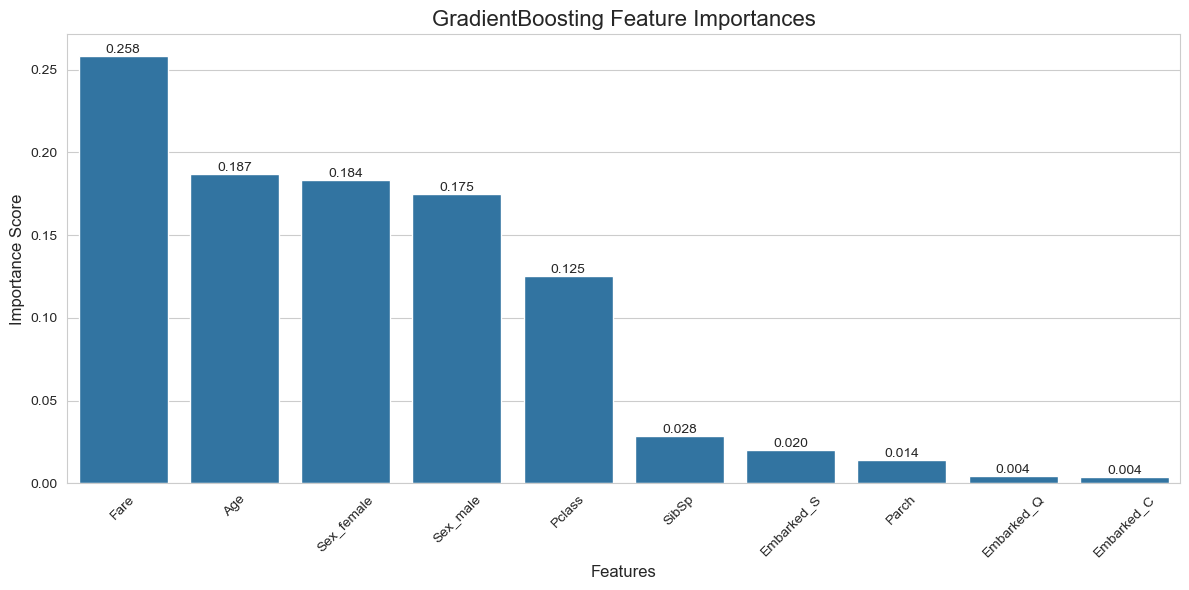

In [91]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=grad_imp_feats, x="feature", y="importance")

# Bar üstüne değer yazdırma
ax.bar_label(ax.containers[0], fmt="%.3f")

# Başlık
plt.title("GradientBoosting Feature Importances", fontsize=16)

# Eksen isimleri
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# X label döndürme
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

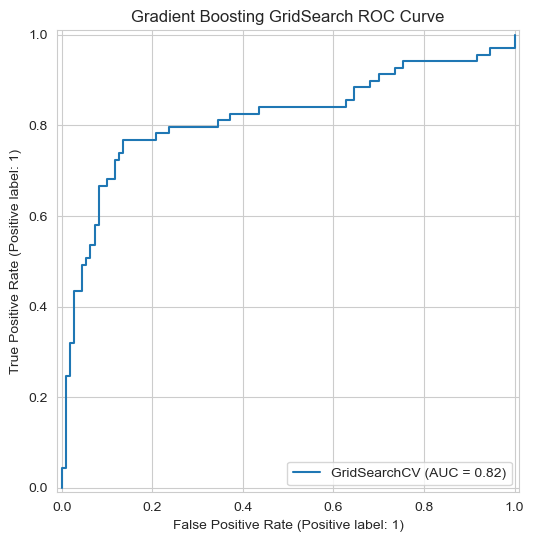

In [92]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(gb_grid, X_valid, y_valid)

plt.title(f"Gradient Boosting GridSearch ROC Curve")
plt.show()

### XGBoost: Extreme Gradient Boosting Modelling and Model Performance

In [93]:
xgb = XGBClassifier(random_state = 42).fit(X_train, y_train)

In [94]:
eval_metric(xgb, X_train, y_train, X_valid, y_valid)

#Eğitim Seti (Train_Set) Performansı: Model eğitim setinde %97 gibi mükemmel bir doğruluk (accuracy) oranına ulaşmıştır. Doğrulama Seti (Valid_Test_Set) Performansı: Test setindeki %82'lik başarı elde etmiş . 
#Eğitim (%97) ve test (%82) skorları arasındaki %15'lik fark, modelde belirgin bir "overfitting" (aşırı öğrenme) durumu olduğunu işaret etmektedir
#Precision (0.76): Model "hayatta kaldı" tahmini yaptığında %76 oranında haklı çıkmaktadır.
#Recall (0.75): Gerçekten hayatta kalan yolcuların %75'i model tarafından doğru tespit edilmiştir.
# F1-Score (0.76): Hassasiyet ve duyarlılık arasındaki bu denge, modelin her iki hata türüne (yanlış pozitif ve yanlış negatif) karşı tutarlı bir performans sergilediğini gösterir. 
#Confusion Matrix Verileri Doğrulama setindeki (179 yolcu) sonuçlara göre: Doğru Tahminler: 94 kişi "öldü" (Class 0), 52 kişi "sağ kaldı" (Class 1) olarak tam doğrulukla tahmin edilmiştir.

Valid_Test_Set
[[94 16]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179


Train_Set
[[432   7]
 [ 12 261]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       439
           1       0.97      0.96      0.96       273

    accuracy                           0.97       712
   macro avg       0.97      0.97      0.97       712
weighted avg       0.97      0.97      0.97       712



In [95]:
xgb_model = XGBClassifier(random_state=42)

param_grid = {
    "n_estimators": [150,200,250],
    "max_depth": [4,5,6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [0.5, 1, 2],
    "gamma": [0.1, 0.5, 1],
    "reg_alpha": [8, 9],
    "reg_lambda": [8,9]
}

In [96]:
xgb_grid = GridSearchCV(xgb_model, param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=2, return_train_score=True).fit(X_train, y_train)

Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


In [97]:
xgb_grid.best_params_

{'colsample_bytree': 0.7,
 'gamma': 0.5,
 'learning_rate': 0.05,
 'max_depth': 4,
 'min_child_weight': 0.5,
 'n_estimators': 150,
 'reg_alpha': 8,
 'reg_lambda': 8,
 'subsample': 0.8}

In [98]:
xgb_grid.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=0.5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [99]:
xgb_grid.best_score_

np.float64(0.7255986345572422)

In [100]:
y_pred = xgb_grid.predict(X_valid)

xgb_accuracy = accuracy_score(y_valid, y_pred)
xgb_precision = precision_score(y_valid, y_pred)
xgb_recall = recall_score( y_valid, y_pred)
xgb_f1 = f1_score(y_valid, y_pred)
xgb_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(xgb_grid, X_train, y_train, X_valid, y_valid)
# Model, Eğitim Setinde %81, Doğrulama Setinde %80 doğruluk (accuracy) oranına ulaşmıştır.Eğitim ve test skorlarının neredeyse eşit olması (%1 fark), modelin veriyi ezberlemediğini, aksine Titanic veri setindeki temel hayatta kalma
# mantığını mükemmel şekilde genellediğini gösterir. 
#Precision (0.80): Model bir yolcu için "hayatta kaldı" tahmini yaptığında %80 oranında haklı çıkmaktadır. Bu yüksek kesinlik, modelin yanlış pozitif (hayatta kalmadığı halde kaldı denilenler) hata payını minimize ettiğini kanıtlar
# Recall (0.65): Gerçekten hayatta kalan yolcuların %65'i doğru tespit edilmiştir. Recall değerinin eğitim setinde de %67 olması, modelin bu sınıfı yakalama gücünün tesadüfi değil, öğrenilmiş bir kararlılıkta olduğunu gösterir.
# F1-Score (0.72): Hassasiyet ve duyarlılık arasındaki denge, modelin her iki sınıfa karşı da güvenilir tahminler ürettiğini doğrular.

Valid_Test_Set
[[99 11]
 [24 45]]
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


Train_Set
[[390  49]
 [ 89 184]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       439
           1       0.79      0.67      0.73       273

    accuracy                           0.81       712
   macro avg       0.80      0.78      0.79       712
weighted avg       0.80      0.81      0.80       712



#### Feature_Importances XGBoost

In [101]:
model =XGBClassifier(colsample_bytree=0.7, gamma=0.5, learning_rate=0.05,max_depth=4, min_child_weight=0.5, n_estimators=150, reg_alpha=8, reg_lambda=8, subsample=0.8, random_state = 42)
model.fit(X_train, y_train)
model.feature_importances_

array([0.06621163, 0.04943014, 0.03940742, 0.03280478, 0.03843328,
       0.31757945, 0.38546026, 0.02218376, 0.02783003, 0.02065922],
      dtype=float32)

In [102]:
feature_names = preprocessor.get_feature_names_out()

xgb_imp_feats = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_imp_feats
#Cinsiyet Faktörünün Ezici Dominansı (Sex_male & Sex_female):
    # Model karar verme gücünün yaklaşık %70'i (0.385 + 0.317) doğrudan cinsiyet değişkenlerine dayanmaktadır.Bu durum, Titanic felaketindeki "önce kadınlar ve çocuklar" kuralının model tarafından matematiksel olarak en belirleyici 
    #faktör olarak kodlandığını gösterir.
# Sosyo-Ekonomik Durum ve Demografi (Pclass & Age)
    #Pclass (Yolcu Sınıfı - %6.6) ve Fare (Bilet Ücreti - %3.8): Ekonomik göstergeler toplamda yaklaşık %10'luk bir ağırlığa sahiptir.
    #Age (Yaş - %4.9): Yaş değişkeni, demografik bir filtre olarak modelin dördüncü en önemli değişkenidir. 
#Sosyal Bağlar ve Aile Yapısı (SibSp & Parch)
    #SibSp (%3.9) ve Parch (%3.2): Gemideki aile üyelerinin sayısı, modelin tahmin gücüne toplamda %7'nin üzerinde bir katkı sağlamaktadır. 
#Coğrafi Giriş Noktaları (Embarked)
    #Embarked_Q, C, S (Toplam %7): Yolcuların biniş limanlarının (Cherbourg, Queenstown, Southampton) model üzerindeki etkisi, cinsiyet ve sınıf kadar baskın olmasa da, belirli bir ağırlığa sahiptir. 
#Model, Titanic felaketindeki hayatta kalma dinamiklerini tarihsel gerçeklikle uyumlu bir şekilde Cinsiyet ve Sosyal Statü ekseninde başarıyla modellemiştir. 

,feature,importance
6,Sex_male,0.385460
5,Sex_female,0.317579
0,Pclass,0.066212
1,Age,0.049430
2,SibSp,0.039407
4,Fare,0.038433
3,Parch,0.032805
8,Embarked_Q,0.027830
7,Embarked_C,0.022184
9,Embarked_S,0.020659


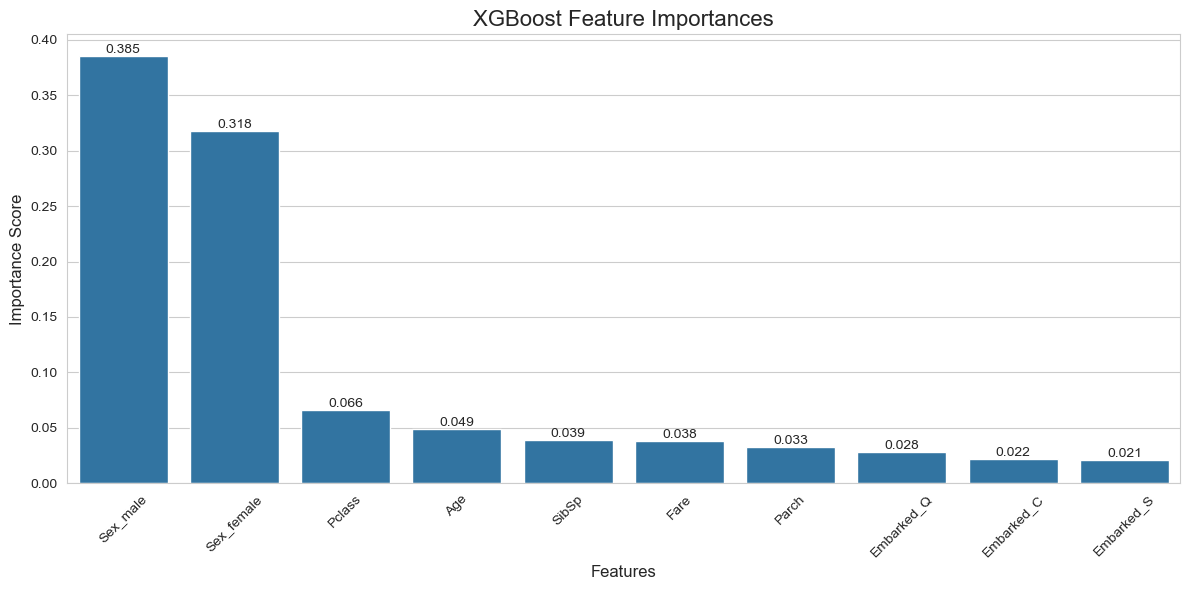

In [103]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=xgb_imp_feats, x="feature", y="importance")

# Bar üstüne değer yazdırma
ax.bar_label(ax.containers[0], fmt="%.3f")

# Başlık
plt.title("XGBoost Feature Importances", fontsize=16)

# Eksen isimleri
plt.xlabel("Features", fontsize=12) 
plt.ylabel("Importance Score", fontsize=12)

# X label döndürme
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

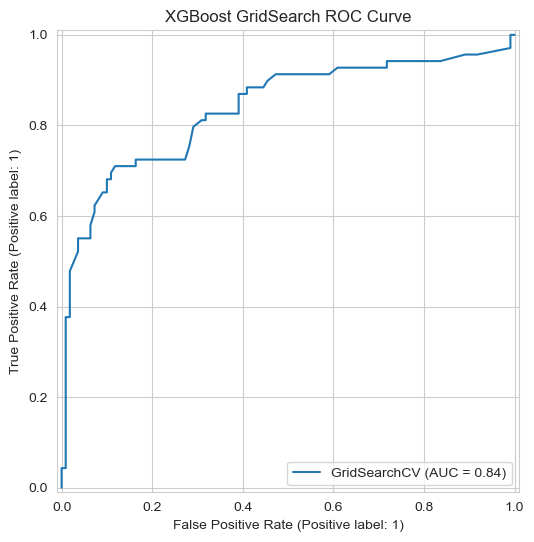

In [104]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(xgb_grid, X_valid, y_valid)

plt.title(f"XGBoost GridSearch ROC Curve")
plt.show()

### Light GBM Modelling and Model Performance  

In [105]:
lgbm_model = LGBMClassifier(random_state=42).fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [106]:
eval_metric(lgbm_model, X_train, y_train, X_valid, y_valid)
#Eğitim (%95) ve test (%79) sonuçları arasındaki %16'lık fark, modelde belirgin bir "overfitting" (aşırı öğrenme) durumu olduğunu işaret etmektedir. 
# LGBM gibi güçlü algoritmalar base model aşamasında veriyi ezberleme eğilimindedir; bu fark, modelin daha fazla düzenlileştirme (regularization) veya hiperparametre optimizasyonuna ihtiyacı olduğunu doğrular
# Precision (0.76): Model bir yolcu için "hayatta kaldı" tahmini yaptığında %76 oranında haklı çıkmaktadır.
# Recall (0.65): Gerçekten hayatta kalan yolcuların %65'i model tarafından doğru yakalanmıştır.
# F1-Score (0.72): Hassasiyet ve duyarlılık arasındaki denge, bir base model için makul bir başlangıç seviyesidir ancak optimizasyonla (GridSearchCV) %75-80 bandına çekilebilir.

Valid_Test_Set
[[95 15]
 [22 47]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       110
           1       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179


Train_Set
[[425  14]
 [ 20 253]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       439
           1       0.95      0.93      0.94       273

    accuracy                           0.95       712
   macro avg       0.95      0.95      0.95       712
weighted avg       0.95      0.95      0.95       712



In [107]:
model = LGBMClassifier(random_state=42)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'accuracy', 'precision_macro', 'recall_macro',
                            'f1_macro', 'roc_auc_ovr'
                        ],
                        cv=10,
                       return_train_score=True)

df_scores = pd.DataFrame(scores, index=range(1, 11))
mean_scores = df_scores.mean()[2:]

print(mean_scores)

[LightGBM] [Info] Number of positive: 245, number of negative: 395
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382812 -> initscore=-0.477628
[LightGBM] [Info] Start training from score -0.477628
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [108]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'num_leaves': [15, 16, 17],  
    'max_depth': [3, 4, 5],     
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0, 0.1, 1],       
    'reg_lambda': [0, 0.1, 1]          
}


In [109]:
lgbm_model = LGBMClassifier(random_state=42)

lgbm_grid = GridSearchCV(estimator=lgbm_model,
                         param_grid=param_grid,
                         cv=5,
                         scoring='f1',
                         n_jobs=-1,
                         return_train_score=True).fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [110]:
lgbm_grid.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 100,
 'num_leaves': 16,
 'reg_alpha': 1,
 'reg_lambda': 0.1,
 'subsample': 0.7}

In [111]:
lgbm_grid.best_estimator_

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=5,
               num_leaves=16, random_state=42, reg_alpha=1, reg_lambda=0.1,
               subsample=0.7)

In [112]:
lgbm_grid.best_score_

np.float64(0.7652103213747988)

In [113]:
y_pred = lgbm_grid.predict(X_valid)

lgbm_accuracy = accuracy_score(y_valid, y_pred)
lgbm_precision = precision_score(y_valid, y_pred)
lgbm_recall = recall_score( y_valid, y_pred)
lgbm_f1 = f1_score(y_valid, y_pred)
lgbm_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(lgbm_grid, X_train, y_train,X_valid, y_valid)

# LightGBM base modelde eğitim başarısı %95, test başarısı %79 iken (%16 fark); GridSearchCV sonrası bu oranlar Eğitimde %87, Doğrulamada %81 olarak gerçekleşmiştir.
# Eğitim ve test skorları arasındaki farkın %6'ya inmesi, modelin veriyi ezberlemek yerine temel kalıpları öğrendiğinin en net kanıtıdır.
# Precision (Kesinlik - 0.84): Model bir yolcu için "hayatta kaldı" dediğinde %84 oranında haklı çıkmaktadır.
# Recall (Duyarlılık - 0.62): Gerçekten hayatta kalan yolcuların %62'si model tarafından doğru tespit edilmiştir. 
# F1-Score (0.72): Bu metrik, modelin hayatta kalanları yakalama ve doğrulama konusundaki genel dengesini temsil etmektedir.

Valid_Test_Set
[[102   8]
 [ 26  43]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179


Train_Set
[[417  22]
 [ 68 205]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       439
           1       0.90      0.75      0.82       273

    accuracy                           0.87       712
   macro avg       0.88      0.85      0.86       712
weighted avg       0.88      0.87      0.87       712



#### Feature_Importances LGBMClassifier

In [114]:
model =LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, num_leaves=16, reg_alpha=1, reg_lambda=0.1, subsample=0.7,random_state=42)
model.fit(X_train, y_train)
model.feature_importances_

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

array([ 94, 320,  52,  13, 417,  68,  16,  23,   0,  52], dtype=int32)

In [115]:
feature_names = preprocessor.get_feature_names_out()

lgbm_imp_feats = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

lgbm_imp_feats


,feature,importance
4,Fare,417
1,Age,320
0,Pclass,94
5,Sex_female,68
2,SibSp,52
9,Embarked_S,52
7,Embarked_C,23
6,Sex_male,16
3,Parch,13
8,Embarked_Q,0


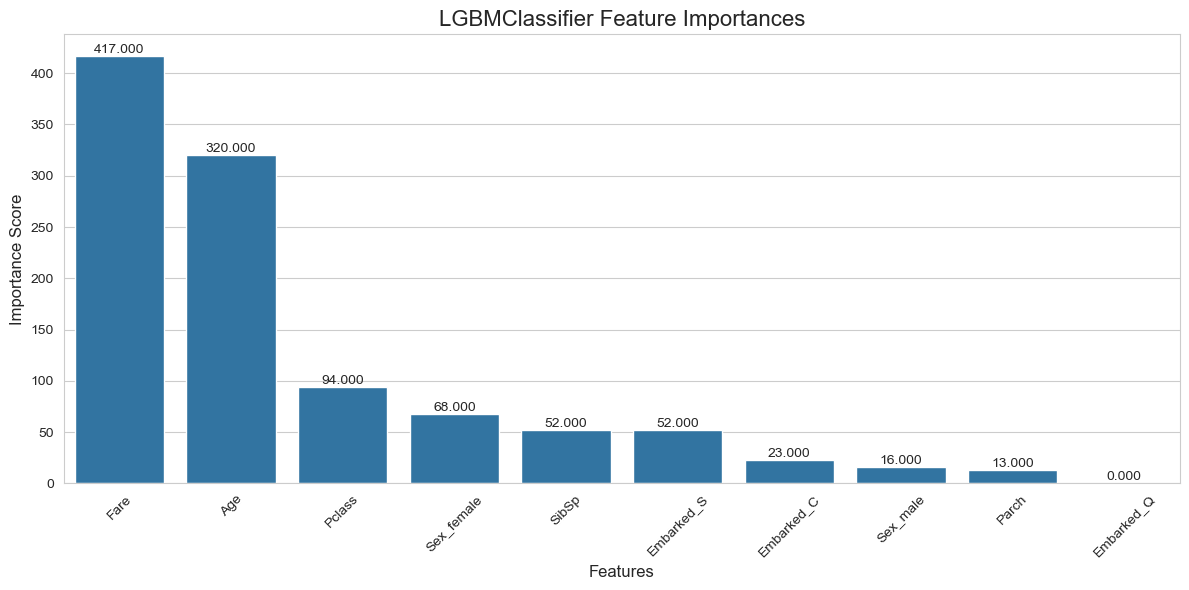

In [116]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=lgbm_imp_feats, x="feature", y="importance")

# Bar üstüne değer yazdırma
ax.bar_label(ax.containers[0], fmt="%.3f")

# Başlık
plt.title("LGBMClassifier Feature Importances", fontsize=16)

# Eksen isimleri
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# X label döndürme
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

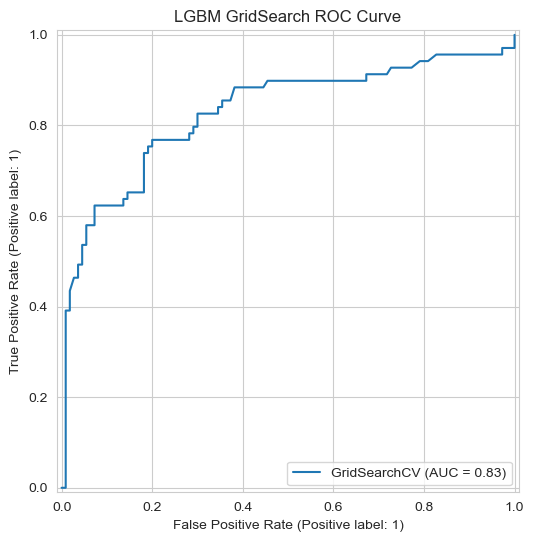

In [117]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(lgbm_grid, X_valid, y_valid)

plt.title(f"LGBM GridSearch ROC Curve")
plt.show()

### CatBoost (Categorical Boosting)

In [118]:
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [119]:
dfcat = train.copy()
dfcat.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [120]:
dfcat.duplicated().sum()

np.int64(0)

In [121]:
dfcat.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [122]:
dfcat['Age'].fillna(dfcat['Age'].median(), inplace=True) # numeric featurelerde bulunan missing vakuları median ile doldurduk

dfcat['Embarked'].fillna(dfcat['Embarked'].mode()[0], inplace=True) # categoric featurelerde bulunan missing vakuları mod ile doldurduk

dfcat.drop(columns="Cabin", inplace=True) #  687 tane NaN value missing value vardır. bu sebeple drop ettik

In [123]:
dfcat.isnull().sum().sum()

np.int64(0)

In [124]:
dfcat.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

# Veri eda sürecinde PassengerId, Name ve Ticket değişkenleri modelleme aşamasından çıkarılmıştır. 
# PassengerId yalnızca benzersiz kimlik bilgisi içerdiği için tahminleme açısından anlamlı bilgi sağlamamaktadır. 
# Name değişkeni yüksek kardinaliteye sahip olduğundan doğrudan modele dahil edilmemiş,drop edilmiştir. 
# Ticket değişkeni ise düzensiz ve çok fazla benzersiz kategori içerdiği için model performansına katkısı sınırlı görülmüş ve veri setinden çıkarılmıştır. Bu işlem ile veri seti sadeleştirilmiş ve modelin gereksiz karmaşıklığı azaltılmıştır.
# #  687 tane NaN value missing value vardır. bu sebeple drop ettik


In [125]:
dfcat.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [126]:
X_cat= dfcat.drop(["Survived"], axis=1 )
y_cat = dfcat["Survived"]

In [127]:
X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=101)

In [128]:
X_valid_cat.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.500,S
700,1,female,18.0,1,0,227.525,C
748,1,male,19.0,1,0,53.100,S
751,3,male,6.0,0,1,12.475,S
481,2,male,28.0,0,0,0.000,S


In [129]:
X_train_cat.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
733,2,male,23.0,0,0,13.00,S
857,1,male,51.0,0,0,26.55,S
81,3,male,29.0,0,0,9.50,S
319,1,female,40.0,1,1,134.50,C
720,2,female,6.0,0,1,33.00,S


In [130]:
categorical_features = list(X_train_cat.select_dtypes(include="object").columns)
categorical_features

['Sex', 'Embarked']

In [131]:
from catboost import CatBoostClassifier, Pool  

train_pool = Pool(X_train_cat, y_train_cat, cat_features = categorical_features)
valid_pool = Pool(X_valid_cat, y_valid_cat, cat_features = categorical_features)

In [132]:
cat_model = CatBoostClassifier(random_state=42)

In [133]:
cat_model.fit(X_train_cat, y_train_cat, cat_features = categorical_features)

Learning rate set to 0.008911
0:	learn: 0.6881735	total: 183ms	remaining: 3m 2s
1:	learn: 0.6820413	total: 209ms	remaining: 1m 44s
2:	learn: 0.6760896	total: 232ms	remaining: 1m 17s
3:	learn: 0.6709102	total: 246ms	remaining: 1m 1s
4:	learn: 0.6654219	total: 266ms	remaining: 52.9s
5:	learn: 0.6598099	total: 288ms	remaining: 47.7s
6:	learn: 0.6551096	total: 309ms	remaining: 43.8s
7:	learn: 0.6508422	total: 320ms	remaining: 39.7s
8:	learn: 0.6473006	total: 346ms	remaining: 38s
9:	learn: 0.6434567	total: 369ms	remaining: 36.5s
10:	learn: 0.6391460	total: 389ms	remaining: 34.9s
11:	learn: 0.6340414	total: 419ms	remaining: 34.5s
12:	learn: 0.6304774	total: 436ms	remaining: 33.1s
13:	learn: 0.6278848	total: 447ms	remaining: 31.5s
14:	learn: 0.6238694	total: 475ms	remaining: 31.2s
15:	learn: 0.6213840	total: 487ms	remaining: 29.9s
16:	learn: 0.6175888	total: 512ms	remaining: 29.6s
17:	learn: 0.6134010	total: 543ms	remaining: 29.6s
18:	learn: 0.6088819	total: 568ms	remaining: 29.3s
19:	learn: 

CatBoostClassifier(random_state=42)

In [134]:
cat_model.fit(X_train_cat, y_train_cat, cat_features = categorical_features, eval_set=(X_valid_cat, y_valid_cat), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.029139
0:	learn: 0.6771071	test: 0.6774187	best: 0.6774187 (0)	total: 14.3ms	remaining: 14.3s
1:	learn: 0.6581385	test: 0.6589778	best: 0.6589778 (1)	total: 48.7ms	remaining: 24.3s
2:	learn: 0.6405961	test: 0.6418260	best: 0.6418260 (2)	total: 86.8ms	remaining: 28.8s
3:	learn: 0.6261462	test: 0.6277477	best: 0.6277477 (3)	total: 113ms	remaining: 28.2s
4:	learn: 0.6113728	test: 0.6143492	best: 0.6143492 (4)	total: 142ms	remaining: 28.3s
5:	learn: 0.5969048	test: 0.6012860	best: 0.6012860 (5)	total: 165ms	remaining: 27.4s
6:	learn: 0.5862359	test: 0.5908657	best: 0.5908657 (6)	total: 194ms	remaining: 27.5s
7:	learn: 0.5726821	test: 0.5783600	best: 0.5783600 (7)	total: 228ms	remaining: 28.2s
8:	learn: 0.5598752	test: 0.5656894	best: 0.5656894 (8)	total: 257ms	remaining: 28.2s
9:	learn: 0.5541893	test: 0.5603751	best: 0.5603751 (9)	total: 268ms	remaining: 26.5s
10:	learn: 0.5481270	test: 0.5543613	best: 0.5543613 (10)	total: 289ms	remaining: 25.9s
11:	learn: 0.539039

CatBoostClassifier(random_state=42)

In [135]:
eval_metric(cat_model, X_train_cat, y_train_cat,X_valid_cat, y_valid_cat)

# Model, Eğitim Setinde %85, Doğrulama Setinde %83 doğruluk (accuracy) oranına ulaşmıştır.Eğitim ve test skorları arasındaki farkın sadece %2 olması, CatBoost'un veriyi ezberlemeden (overfitting) öğrendiğinin en güçlü kanıtıdır.
# Precision (0.93): Doğrulama setinde "hayatta kaldı" dediğiniz kişilerin %93'ü gerçekten hayatta kalmıştır. Sadece 4 kişide yanılmanız, modelin çok düşük bir "Yanlış Pozitif" (False Positive) oranına sahip olduğunu gösterir.
# Recall (0.68): Hayatta kalan 80 kişiden 54'ünü doğru tespit edebilmiştir. Precision değerine göre daha düşük olan bu oran, modelin "hayatta kalma" tahmini yaparken oldukça muhafazakâr ve "garantici" davrandığını kanıtlar.
# F1-Score (0.78): Hassasiyet ve duyarlılık arasındaki bu denge, base model için oldukça güçlü bir temel oluşturmaktadır.


Valid_Test_Set
[[95  4]
 [26 54]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.86        99
           1       0.93      0.68      0.78        80

    accuracy                           0.83       179
   macro avg       0.86      0.82      0.82       179
weighted avg       0.85      0.83      0.83       179


Train_Set
[[425  25]
 [ 81 181]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       450
           1       0.88      0.69      0.77       262

    accuracy                           0.85       712
   macro avg       0.86      0.82      0.83       712
weighted avg       0.85      0.85      0.85       712



In [136]:
cat_model = CatBoostClassifier(random_state=42, verbose=0)

scores = cross_validate(cat_model,
                        X_train_cat,
                        y_train_cat,
                        scoring=['accuracy', 'precision', 'recall', 'f1','roc_auc'],
                        cv=5,
                        return_train_score=True,
                        params={'cat_features': categorical_features}
)

df_scores = pd.DataFrame(scores, index=range(1, 6))
df_scores.mean()[2:]

test_accuracy      0.813218
train_accuracy     0.879572
test_precision     0.810536
train_precision    0.905267
test_recall        0.644920
train_recall       0.751989
test_f1            0.717259
train_f1           0.820660
test_roc_auc       0.855971
train_roc_auc      0.940872
dtype: float64

In [138]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'depth': [3, 4, 5, 6],
    'l2_leaf_reg': [3, 5, 7, 9],
    'grow_policy': ['SymmetricTree','Depthwise'],
    'early_stopping_rounds': [20],
    }

In [139]:
cat_grid = GridSearchCV(estimator=cat_model,
                        param_grid=param_grid,
                        cv=3,
                        scoring='f1',
                        n_jobs=-1,
                        verbose=2,
                        return_train_score=True,
                        ).fit(X_train_cat, y_train_cat, cat_features = categorical_features)

Fitting 3 folds for each of 288 candidates, totalling 864 fits


In [140]:
cat_grid.best_params_

{'depth': 4,
 'early_stopping_rounds': 20,
 'grow_policy': 'Depthwise',
 'iterations': 100,
 'l2_leaf_reg': 5,
 'learning_rate': 0.05}

In [141]:
cat_grid.best_estimator_

CatBoostClassifier(depth=4, early_stopping_rounds=20, grow_policy='Depthwise', iterations=100, l2_leaf_reg=5, learning_rate=0.05, random_state=42, verbose=0)

In [142]:
cat_grid.best_score_

np.float64(0.7390904828879513)

In [143]:
y_pred = cat_grid.predict(X_valid_cat)

cat_accuracy = accuracy_score(y_valid, y_pred)
cat_precision = precision_score(y_valid, y_pred)
cat_recall = recall_score( y_valid, y_pred)
cat_f1 = f1_score(y_valid, y_pred)
cat_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(cat_grid, X_train_cat, y_train_cat,X_valid_cat, y_valid_cat)

# Model, Eğitim Setinde %84, Doğrulama Setinde %82 doğruluk (accuracy) oranına ulaşmıştır.Eğitim ve test skorları arasındaki farkın sadece %2 olması, modelveriyi ezberlemediğini (overfitting yapmadığını) kanıtlar. 
# Precision (0.93): Doğrulama setinde "hayatta kaldı" dediğiniz kişilerin %93'ü gerçekten hayatta kalmıştır.
# Recall (0.65): Gerçekten hayatta kalan 80 kişiden 52'si tespit edilebilmiştir. Precision'a kıyasla daha düşük olan bu oran, modelin sadece çok emin olduğu durumlarda "hayatta kaldı" tahmini yaptığını gösterir.
# F1-Score (0.76): Hassasiyet ve duyarlılık arasındaki dengeli başarı, modelin genel başarısını doğrular.

Valid_Test_Set
[[95  4]
 [28 52]]
              precision    recall  f1-score   support

           0       0.77      0.96      0.86        99
           1       0.93      0.65      0.76        80

    accuracy                           0.82       179
   macro avg       0.85      0.80      0.81       179
weighted avg       0.84      0.82      0.82       179


Train_Set
[[422  28]
 [ 85 177]]
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       450
           1       0.86      0.68      0.76       262

    accuracy                           0.84       712
   macro avg       0.85      0.81      0.82       712
weighted avg       0.84      0.84      0.84       712



#### Feature_Importances CatBoost

In [144]:
model = CatBoostClassifier( random_state=42, verbose=0)
model.fit(X_train_cat, y_train_cat, cat_features=categorical_features)
model.feature_importances_

array([14.74820565, 35.06562027, 16.9772095 ,  5.95513634,  3.02107004,
       13.66532017, 10.56743804])

In [145]:
cat_imp_feats = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

cat_imp_feats

,feature,importance
1,Sex,35.065620
2,Age,16.977209
0,Pclass,14.748206
5,Fare,13.665320
6,Embarked,10.567438
3,SibSp,5.955136
4,Parch,3.021070


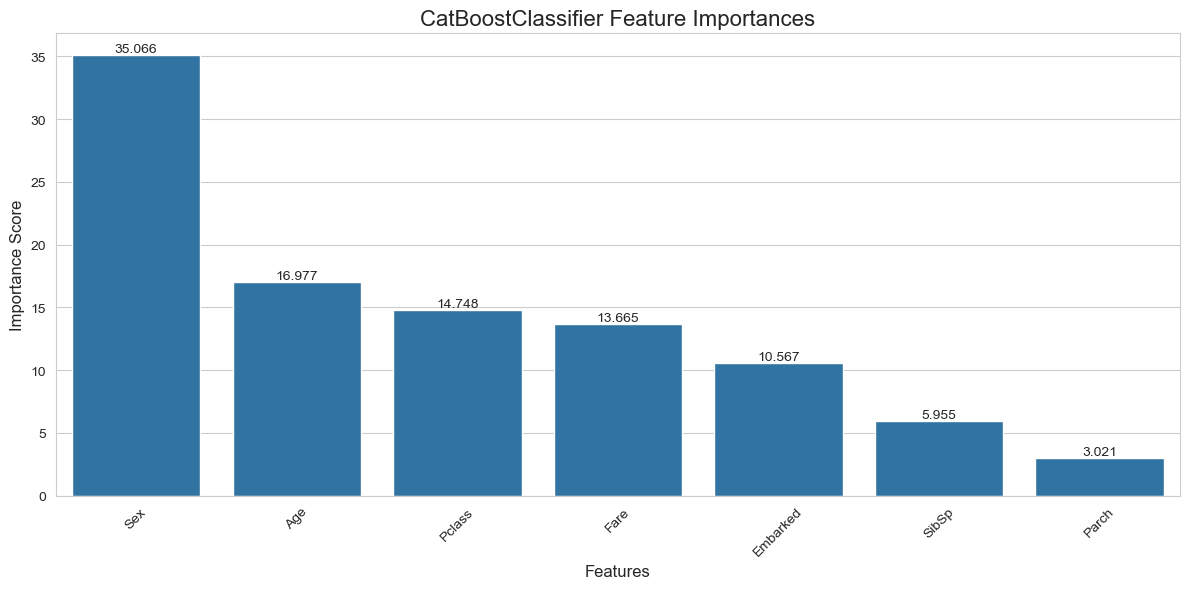

In [146]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=cat_imp_feats, x="feature", y="importance")

# Bar üstüne değer yazdırma
ax.bar_label(ax.containers[0], fmt="%.3f")

# Başlık
plt.title("CatBoostClassifier Feature Importances", fontsize=16)

# Eksen isimleri
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# X label döndürme
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

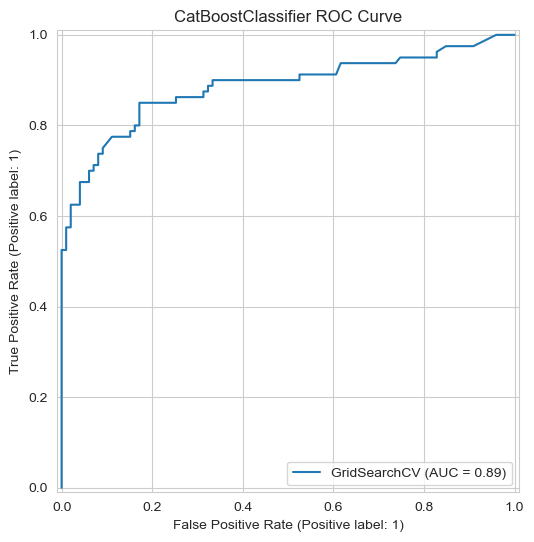

In [147]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(cat_grid, X_valid_cat, y_valid_cat)

plt.title(f"CatBoostClassifier ROC Curve")
plt.show()

## Comparing Models

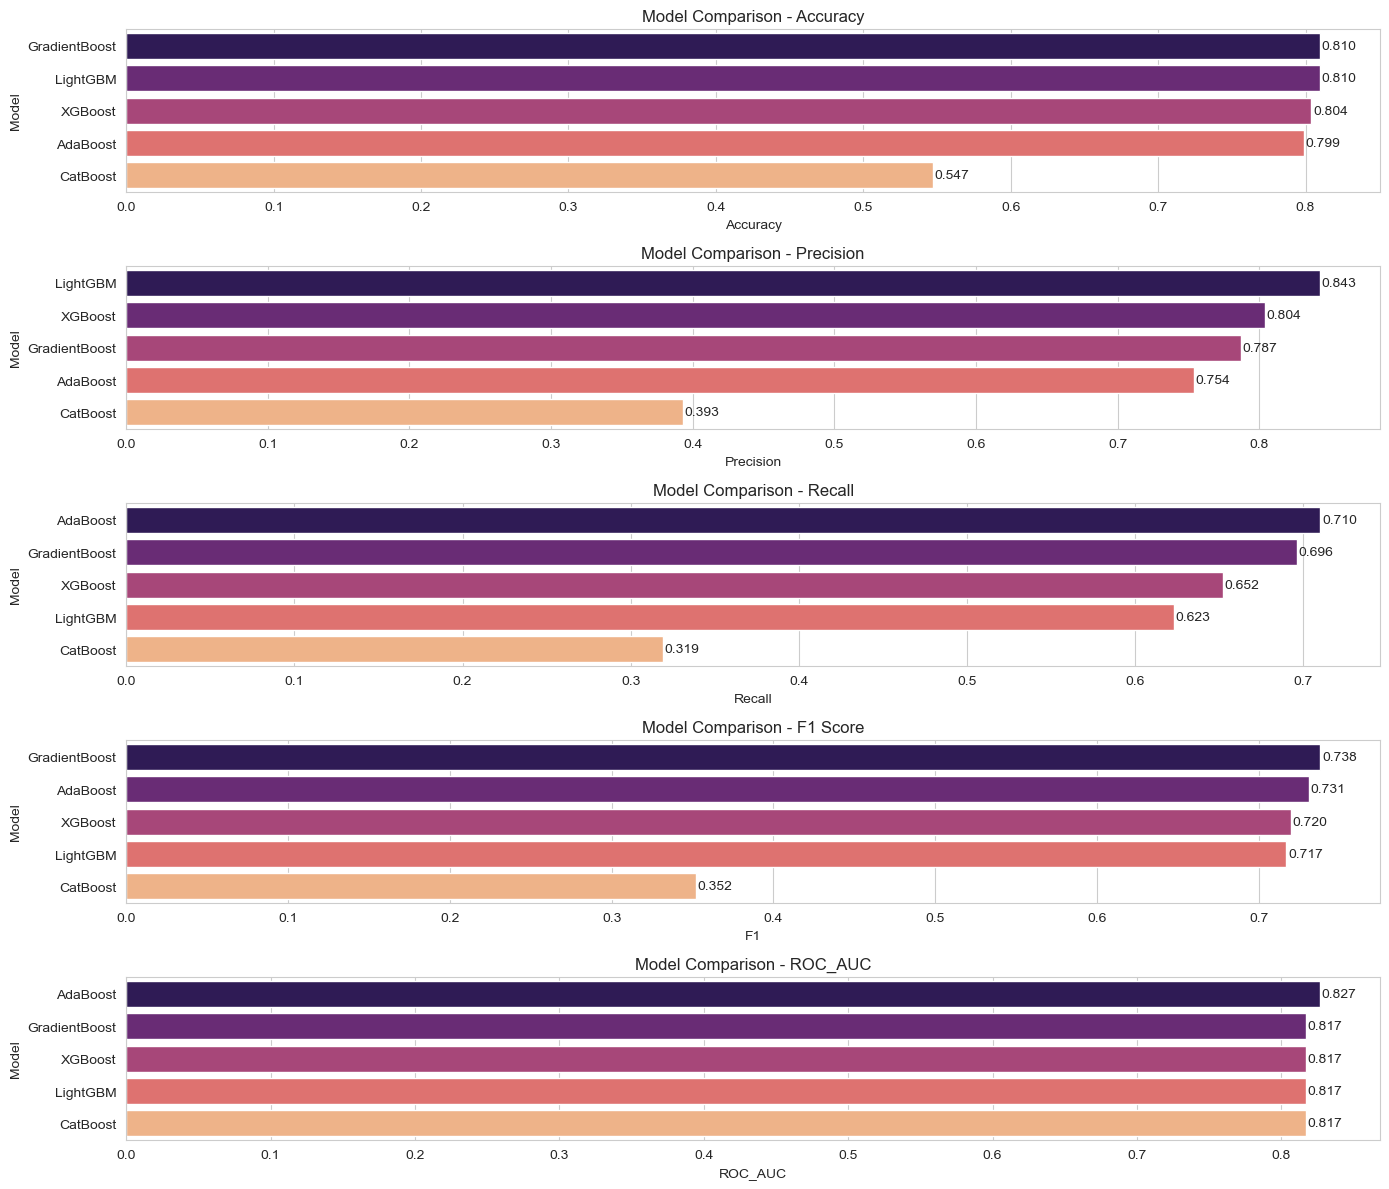

In [148]:
compare = pd.DataFrame({
    "Model": ["AdaBoost", "GradientBoost", "XGBoost", "LightGBM", "CatBoost"],
    "Accuracy": [ada_accuracy, gb_accuracy, xgb_accuracy, lgbm_accuracy, cat_accuracy],
    "Precision": [ada_precision, gb_precision, xgb_precision, lgbm_precision, cat_precision],
    "Recall": [ada_recall, gb_recall, xgb_recall, lgbm_recall, cat_recall],
    "F1": [ada_f1, gb_f1, xgb_f1, lgbm_f1, cat_f1],
    "ROC_AUC": [ada_auc, gb_auc, xgb_auc, lgbm_auc, cat_auc ]})

# Virgülden sonra 3 basamak
compare = compare.round(3)
# Label fonksiyonu
def labels(ax):

    for p in ax.patches:

        width = p.get_width()

        ax.text( width + 0.001, p.get_y() + p.get_height() / 2, f"{width:.3f}", ha='left', va='center', fontsize=10)

# Figure
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

# Accuracy
compare_acc = compare.sort_values(by="Accuracy", ascending=False)
ax0 = sns.barplot( x="Accuracy", y="Model", data=compare_acc, palette="magma", ax=axes[0])
axes[0].set_title("Model Comparison - Accuracy")
labels(ax0)

# Precision
compare_precision = compare.sort_values(by="Precision", ascending=False)
ax1 = sns.barplot(x="Precision", y="Model", data=compare_precision, palette="magma", ax=axes[1])
axes[1].set_title("Model Comparison - Precision")
labels(ax1)

# Recall
compare_recall = compare.sort_values(by="Recall", ascending=False)
ax2 = sns.barplot( x="Recall", y="Model", data=compare_recall, palette="magma", ax=axes[2])
axes[2].set_title("Model Comparison - Recall")
labels(ax2)

# F1
compare_f1 = compare.sort_values(by="F1", ascending=False)
ax3 = sns.barplot(x="F1", y="Model", data=compare_f1, palette="magma", ax=axes[3])
axes[3].set_title("Model Comparison - F1 Score")
labels(ax3)

# ROC_AUC
compare_auc = compare.sort_values(by="ROC_AUC", ascending=False)
ax4 = sns.barplot( x="ROC_AUC", y="Model", data=compare_auc, palette="magma", ax=axes[4])
axes[4].set_title("Model Comparison - ROC_AUC")
labels(ax4)

plt.tight_layout()
plt.show()

### Final Model Selection

Titanic veri seti üzerinde AdaBoost, GradientBoosting, XGBoost, LightGBM ve CatBoost algoritmaları uygulanmış ve modeller Accuracy, Precision, Recall, F1-Score ve ROC-AUC metrikleri ile değerlendirilmiştir.

GridSearchCV optimizasyon sürecinde temel değerlendirme metriği olarak F1-score kullanılmıştır. Bunun nedeni, Titanic veri setinde yalnızca doğruluk (Accuracy) metriğinin yeterli olmaması ve hem Precision hem de Recall değerlerinin dengeli şekilde değerlendirilmek istenmesidir.Yapılan karşılaştırmalar sonucunda:

- GradientBoostingClassifier;
    - Tüm modeller arasında en yüksek F1-score (0.738) değerine ulaşmıştır.
    - Accuracy değeri de en yüksek grup içerisinde yer almıştır (0.810).
    - Recall değeri oldukça güçlüdür (0.696) ve modelin hayatta kalan yolcuları başarılı şekilde yakalayabildiğini göstermektedir.
    - ROC-AUC skorunun yüksek olması (0.817) modelin sınıfları ayırt etme gücünün başarılı olduğunu göstermektedir. 

- AdaBoost modeli Recall ve ROC-AUC açısından güçlü sonuçlar üretmiş olsa da, genel denge açısından GradientBoostingClassifier daha başarılı performans göstermiştir.

- LightGBM modeli çok yüksek Precision üretmesine rağmen Recall değerinin düşük olması nedeniyle hayatta kalan yolcuların bir kısmını kaçırmıştır.

- XGBoost modeli dengeli sonuçlar üretmiş ancak F1-score açısından GradientBoostingClassifier’ın gerisinde kalmıştır.

- CatBoost modeli ise diğer boosting algoritmalarına göre belirgin şekilde düşük performans göstermiştir.

GradientBoostingClassifier özellikle F1-score ve ROC_AUC metriklerinde diğer modellerden daha başarılı sonuçlar üretmesi nedeniyle proje kapsamında final model olarak seçilmiştir. Ayrıca modelin Recall performansının yüksek olması, hayatta kalan yolcuların doğru sınıflandırılmasında daha başarılı olduğunu göstermektedir.

In [150]:
grad_imp_feats #Feature_Importances GradientBoostingClassifier
#Titanic veri setinde elde ettiğiniz GradientBoostingClassifier özellik önem düzeyi (Feature Importance) verileri, modelin karar mekanizmasının çok büyük bir kısmının sadece
#beş ana değişkene dayandığı,Fare, Age, Sex_female, Sex_male ve Pclass değişkenlerinin toplam önem ağırlığı yaklaşık %93 seviyesindedir, bu da geri kalan değişkenlerin (SibSp, Embarked, Parch)
#modelin tahmin gücüne katkısının oldukça sınırlı olduğunu göstermektedir
# GradientBoostingClassifier metodunun önem verdiği featureler ["Fare", "Age", "Sex", "Pclass"] seçilerek tekrar scorelar kontrol edilir ve final model oluşturulur.  

,feature,importance
4,Fare,0.258417
1,Age,0.187244
5,Sex_female,0.183502
6,Sex_male,0.174980
0,Pclass,0.125422
2,SibSp,0.028388
9,Embarked_S,0.020041
3,Parch,0.013930
8,Embarked_Q,0.004382
7,Embarked_C,0.003694


In [151]:
selected_features = ["Fare", "Age", "Sex", "Pclass"] #( Feature importance:"Fare", "Age", "Sex", "Pclass") ile tekrar model fit edilir ve scorelar karşılaştırılır 

X = train[selected_features]
y = train["Survived"]

In [152]:
X_test_final = test[selected_features]

In [153]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [154]:
num_features = ["Fare", "Age", "Pclass"]
cat_features = ["Sex"]

In [155]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier

# Numerik pipeline
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategorik pipeline
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
],
verbose_feature_names_out=False).set_output(transform="pandas")

# Final pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# Fit
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fare', 'Age', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex'])],
                                   verbose_feature_names_out=False)),
                ('model', GradientBoostingClassifier(random_state=42))])

In [156]:
eval_metric(pipe, X_train, y_train, X_valid, y_valid)

Valid_Test_Set
[[101   9]
 [ 26  43]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179


Train_Set
[[424  15]
 [ 51 222]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       439
           1       0.94      0.81      0.87       273

    accuracy                           0.91       712
   macro avg       0.91      0.89      0.90       712
weighted avg       0.91      0.91      0.91       712



In [157]:
gb_grid_2 = GradientBoostingClassifier(random_state=42)

pipe = Pipeline([("preprocessor", preprocessor),("model", gb_grid_2)])

param_grid = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__max_features": ["sqrt", "log2", None]
}

In [158]:
gb_grid_2 = GridSearchCV( estimator=pipe,
                          param_grid=param_grid,
                          scoring="f1",
                          cv=5,
                          n_jobs=-1,
                          verbose=2,
                          return_train_score=True
                        )

gb_grid_2.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Fare',
                                                                          'Age',
                                                                          'Pclass']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_outp...
                                                                         ['Sex'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1, 0.15],
                         'model__max_depth': [2, 3, 4],
                         'model__max_features': ['sqrt', 'log2', None],
                         'model__n_estimators': [100, 150, 200, 250],
                         'model__subsample': [0.7, 0.8, 1.0]},
             return_train_score=True, scoring='f1', verbose=2)

In [159]:
gb_grid_2.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': 2,
 'model__max_features': None,
 'model__n_estimators': 200,
 'model__subsample': 0.7}

In [160]:
gb_grid_2.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fare', 'Age', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 GradientBoostingClassifier(max_depth=2, n_estimators=200,
                                            random_state=42, subsample=0.7))])

In [161]:
gb_grid_2.best_score_

np.float64(0.7768031318332154)

In [162]:
y_pred = gb_grid_2.predict(X_valid)
y_pred_proba = gb_grid_2.predict_proba(X_valid)

gb_2_accuracy = accuracy_score(y_valid, y_pred)
gb_2_precision= precision_score(y_valid, y_pred)
gb_2_recall = recall_score( y_valid, y_pred)
gb_2_f1 = f1_score(y_valid, y_pred)
gb_2_auc = roc_auc_score(y_valid, y_pred_proba[:,1])

eval_metric(gb_grid_2, X_train, y_train, X_valid, y_valid)

Valid_Test_Set
[[98 12]
 [22 47]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


Train_Set
[[414  25]
 [ 52 221]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       439
           1       0.90      0.81      0.85       273

    accuracy                           0.89       712
   macro avg       0.89      0.88      0.88       712
weighted avg       0.89      0.89      0.89       712



In [163]:
print("gb_grid_2 Metrics:")

print(f"Accuracy: {gb_2_accuracy:.4f}")
print(f"Precision: {gb_2_precision:.4f}")
print(f"Recall: {gb_2_recall:.4f}")
print(f"F1 Score: {gb_2_f1:.4f}")
print(f"ROC_AUC Score: {gb_2_auc:.4f}")

gb_grid_2 Metrics:
Accuracy: 0.8101
Precision: 0.7966
Recall: 0.6812
F1 Score: 0.7344
ROC_AUC Score: 0.7987


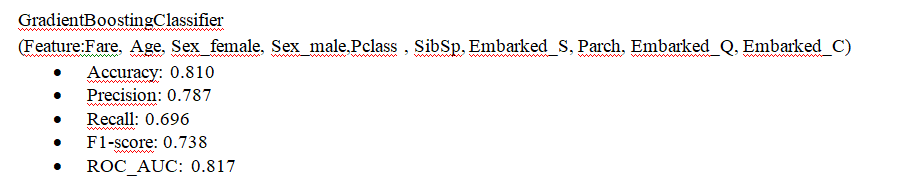




- Feature reduction ( Feature importance:"Fare", "Age", "Sex", "Pclass") uygulanarak daha sade bir model oluşturulmuş olsa da performans metriklerinde düşüş gözlemlendiğinden, daha geniş feature setine (Feature:Fare, Age, Sex_female, Sex_male,Pclass,SibSp,Embarked_S,Parch,Embarked_Q,,Embarked_C) sahip GradientBoostingClassifier final model olarak tercih edilmiştir.

In [164]:
gb_grid.best_params_ # full model ile alınan best_param (Feature:Fare, Age, Sex_female, Sex_male,Pclass,SibSp,Embarked_S,Parch,Embarked_Q,,Embarked_C)

{'learning_rate': 0.1,
 'max_depth': 3,
 'max_features': None,
 'n_estimators': 200,
 'subsample': 0.8}

In [165]:
gb_grid.best_estimator_

GradientBoostingClassifier(n_estimators=200, random_state=42, subsample=0.8)

In [166]:
final_gb_model = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("gradientboost", GradientBoostingClassifier(
        learning_rate=0.1,
        max_depth=3,
        max_features=None,
        n_estimators=200,
        subsample=0.8,
        random_state=42
    ))
])

In [167]:
final_gb_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fare', 'Age', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex'])],
                                   verbose_feature_names_out=False)),
                ('gradientboost',
                 GradientBoostingClassifier(n_estimators=200, random_state=42,
                                            subsample=0.8))])

In [168]:
import pickle

pickle.dump(final_gb_model, open("final_titanic_model.pkl", "wb"))

In [169]:
final_model = pickle.load(open("final_titanic_model.pkl", "rb"))

In [170]:
preds = final_model.predict(df_test)

In [171]:
test_ids =test["PassengerId"]

In [172]:
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": preds
})
submission.to_csv("submission.csv", index=False)

print("✅ Submission file created!")

✅ Submission file created!


In [173]:
submission # full model ile alınan best_param (Feature:Fare, Age, Sex_female, Sex_male,Pclass,SibSp,Embarked_S,Parch,Embarked_Q,,Embarked_C)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
